# Causal Machine Learning for Markdown Price Optimization in Retail

This notebook reproduces the full empirical analysis behind my thesis, from the raw
transactional data all the way to the figures and tables that appear in the final document.
The question I want to answer is a causal one: *how does a markdown discount actually change
weekly sales?* A standard forecasting model can predict demand well, but it cannot separate
the effect of the discount from the reasons a product was discounted in the first place. To
address that, I contrast a conventional predictive baseline with a causal model that isolates
the effect of price on demand.

The analysis is organised in three steps. I first build a predictive baseline, then use it to
decide which modelling specification is most credible, and finally estimate how the price
effect varies across products using a Causal Forest.

---
## 1) Setup and imports

The first cell installs `econml` — which has to be built from source on the cluster — and the
remaining cells load the libraries used throughout the notebook. Restart the kernel before
running if `econml` was installed in a previous session.

In [0]:
try:
    import econml
    print(f"econml {econml.__version__} already installed — skipping build.")
except ImportError:
    import urllib.request
    import tarfile
    import re
    import os
    import shutil

    base_path = f"/tmp/econml_build_{os.getuid()}"
    if os.path.exists(base_path):
        shutil.rmtree(base_path, ignore_errors=True)
    os.makedirs(base_path, exist_ok=True)

    url = "http://pappjam01.intranet.mango.es:8081/repository/pypi-all/packages/econml/0.16.0/econml-0.16.0.tar.gz"
    tar_name = f"{base_path}/econml-0.16.0.tar.gz"

    print("Downloading econml...")
    urllib.request.urlretrieve(url, tar_name)

    print("Extracting...")
    with tarfile.open(tar_name, "r:gz") as tar:
        tar.extractall(path=base_path)

    toml_path = f"{base_path}/econml-0.16.0/pyproject.toml"

    with open(toml_path, encoding="utf-8") as fh:
        content = fh.read()

    content = re.sub(r'^\s*license\s*=\s*.*$', '', content, flags=re.MULTILINE)
    content = re.sub(r'license\s*=\s*\{[^}]*\}', '', content, flags=re.DOTALL)
    content = re.sub(
        r'(\[project\](?:\n.*?(?=\n\[|\Z))?)',
        r'\1\nlicense = {text = "MIT"}\n',
        content,
        flags=re.DOTALL,
    )

    with open(toml_path, "w", encoding="utf-8") as fh:
        fh.write(content)

    cores = str(os.cpu_count() or 8)
    os.environ["CMAKE_BUILD_PARALLEL_LEVEL"] = cores
    os.environ["MAX_JOBS"] = cores
    os.environ["NPY_NUM_BUILD_JOBS"] = cores
    os.environ["TMPDIR"] = "/tmp"

    %pip install {base_path}/econml-0.16.0 --no-build-isolation


Extracting...
Looking in indexes: http://pappjam01.intranet.mango.es:8081/repository/pypi-all/pypi, http://pappjam01.intranet.mango.es:8081/repository/pypi-all/simple
Processing /tmp/econml_build_1003/econml-0.16.0
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/151.9 kB ? eta -:--:--
     ━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/151.9 kB 6.6 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━ 71.7/151.9 kB 1.1 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━ 112.6/151.9 kB 1.0 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━ 133.1/151.9 kB 1.2 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━ 143.4/151.9 kB 923.8 kB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 777.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.0 MB ? eta -:--:--
     ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [0]:
%pip install lightgbm scikit-learn


Looking in indexes: http://pappjam01.intranet.mango.es:8081/repository/pypi-all/pypi, http://pappjam01.intranet.mango.es:8081/repository/pypi-all/simple
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import functions as F
from pyspark.sql import Window
from databricks.connect import DatabricksSession
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

try:
    from econml.grf import CausalForest
    HAS_ECONML = True
except Exception:
    CausalForest = None
    HAS_ECONML = False

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
np.random.seed(42)
print("Setup OK")


Setup OK


---
## 2) Scope and global parameters

Here I fix the scope of the study and the constants that drive the rest of the analysis. The
data is restricted to a single country and division (Spain, Woman) so that the price–demand
relationship is estimated within a homogeneous commercial setting. The following cells also
define the reference discount that every result is compared against, the grid of discounts
used to trace demand curves, and the hyperparameters of the predictive and causal models.

In [0]:
COUNTRIES = ["Spain"]
DIVISIONS = ["Woman"]


def apply_selection(df):
    out = df
    if "country" in out.columns:
        out = out.filter(F.col("country").isin(COUNTRIES))
    if "division" in out.columns:
        out = out.filter(F.col("division").isin(DIVISIONS))
    return out


def selection_join_cols(*dfs):
    return [
        c for c in ("country", "division")
        if all(c in getattr(df, "columns", []) for df in dfs)
    ]


def selection_model_cols(*dfs):
    cols = selection_join_cols(*dfs)
    varying = []
    if len(COUNTRIES) > 1 and "country" in cols:
        varying.append("country")
    if len(DIVISIONS) > 1 and "division" in cols:
        varying.append("division")
    return varying


In [0]:
import os

EPS           = 1e-9
REF_DISCOUNT  = 0.20

DML_SEED = 42

LGB_PARAMS = dict(
    objective="regression", n_estimators=1000, learning_rate=0.01,
    num_leaves=127, min_child_samples=8, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=0.03,
    random_state=DML_SEED, n_jobs=-1, verbose=-1, metric="mape",
)

BASELINE_LGB_PARAMS = dict(
    objective="regression", n_estimators=1000, learning_rate=0.01,
    num_leaves=127, min_child_samples=8, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=0.03,
    random_state=DML_SEED, n_jobs=-1, verbose=-1, metric="l2",
)

# Evaluation / early-stopping policy for nuisance models used by DML / CausalForest.
LGB_NUISANCE_EVAL_METRIC = "mape"

EARLY_STOPPING_ROUNDS = 20
NUISANCE_EARLY_STOPPING_MIN_DELTA = 0.0001

# Causal forest hyperparameters
CF_PARAMS = dict(
    n_estimators=1000,
    min_samples_leaf=80,
    random_state=DML_SEED,
    n_jobs=-1,
)

DISCOUNT_GRID = np.arange(0.20, 0.701, 0.05)

FIG_DIR = "thesis_outputs/figures"
TAB_DIR = "thesis_outputs/tables"
ALL_TABLES_TXT = f"{TAB_DIR}/all_tables_compendium.txt"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

def savefig(name):
    png_path = f"{FIG_DIR}/{name}.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {png_path}")


def save_table(df, name):
    csv_path = f"{TAB_DIR}/{name}.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved table: {csv_path}")


THESIS_FIGURES = [
    "baseline_curve",
    "cate_sales_spec_grid",
    "global_comparison",
    "elasticity_examples_baseline_vs_causal",
    "dml_residualized_treatment_outcome_linear",
]

THESIS_TABLES = [
    "dataset_summary",
    "treatment_support",
    "model_config",
    "nuisance_diagnostics",
    "model_metrics",
    "cate_distribution",
    "curve_quality",
    "optimizer_interface",
    "lgbm_hyperparameters",
    "causal_forest_hyperparameters",
]


def save_all_tables_txt(table_names, output_path=ALL_TABLES_TXT):
    lines = [
        "Thesis Tables Compendium",
        "=======================",
        "",
    ]

    for table_name in table_names:
        csv_path = f"{TAB_DIR}/{table_name}.csv"
        lines.append(f"## {table_name}")
        if os.path.exists(csv_path):
            with open(csv_path, "r", encoding="utf-8") as fh:
                content = fh.read().strip()
            lines.append(content if content else "(empty table)")
        else:
            lines.append(f"(missing table file: {csv_path})")
        lines.append("")

    with open(output_path, "w", encoding="utf-8") as fh:
        fh.write("\n".join(lines).rstrip() + "\n")

    print(f"Saved combined tables TXT: {output_path}")
    return output_path


---
## 3) Loading the data

The training and test sets come from two inference experiments stored on S3 and read through
Databricks. In this section I also reconstruct `shipment_base` — the total number of units a
reference was expected to move during the season — by combining the stock available at the
execution date with the net sales accumulated up to that point. This quantity is used later to
put weekly demand on a comparable scale across products of very different sizes.

In [0]:
TRAIN_PATH = (
    "s3://aws-mng-stg-pricstk-euw1-dev/db_volume/midas/unified_datasets/oraclus/"
    "experiment_double_ml_inference_season_90_exec_time_0700"
)
TEST_PATH = (
    "s3://aws-mng-stg-pricstk-euw1-dev/db_volume/midas/unified_datasets/eureka/"
    "experiment_v1_sin_railes_inference_season_90_exec_week_1_exec_time_0700"
)

spark = DatabricksSession.builder.getOrCreate()

train_spark_raw = spark.read.parquet(TRAIN_PATH)
test_spark_raw  = spark.read.parquet(TEST_PATH)

SELECTION_JOIN_COLS = selection_join_cols(train_spark_raw, test_spark_raw)
SELECTION_MODEL_COLS = selection_model_cols(train_spark_raw, test_spark_raw)

try:
    spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
except Exception:
    pass

print(f"Selection join cols        : {SELECTION_JOIN_COLS}")
print(f"Selection model cols       : {SELECTION_MODEL_COLS}")


Selection join cols        : ['country', 'division']
Selection model cols       : []


In [0]:
train_spark = apply_selection(train_spark_raw)
test_spark = apply_selection(test_spark_raw)

print(f"Countries selected         : {COUNTRIES}")
print(f"Divisions selected         : {DIVISIONS}")
print(f"Join context cols          : {SELECTION_JOIN_COLS}")
print(f"Model context cols         : {SELECTION_MODEL_COLS}")


Countries selected         : ['Spain']
Divisions selected         : ['Woman']
Join context cols          : ['country', 'division']
Model context cols         : []


In [0]:
# shipment_base = stock at execution date + accumulated net sales until execution date.
MAPPING_COUNTRY = {
    "Spain": 20015, "France": 20022, "Germany": 20004, "Italy": 20057,
    "USA": 20180, "Netherlands": 20113, "UK": 20024, "Portugal": 20131, "Poland": 20126,
}
MAPPING_DIVISION = {"Woman": 50746, "Man": 31985, "Kids": 42990}

requested_pairs = pd.MultiIndex.from_product(
    [COUNTRIES, DIVISIONS],
    names=["country", "division"],
).to_frame(index=False)
requested_pairs["id_pais_geografico"] = requested_pairs["country"].map(MAPPING_COUNTRY)
requested_pairs["id_division_mdm"] = requested_pairs["division"].map(MAPPING_DIVISION)

if requested_pairs[["id_pais_geografico", "id_division_mdm"]].isnull().any().any():
    bad_rows = requested_pairs[
        requested_pairs[["id_pais_geografico", "id_division_mdm"]].isnull().any(axis=1)
    ]
    raise ValueError(f"Unsupported country/division in selection: {bad_rows.to_dict('records')}")

requested_pairs_spark = spark.createDataFrame(requested_pairs)
requested_country_ids = requested_pairs_spark.select("id_pais_geografico").dropDuplicates()

sales_dates_df = (
    spark.read.table("pro.edl_pricstk.datafeed_dim_midas_sales_dates")
    .join(F.broadcast(requested_country_ids), on="id_pais_geografico", how="inner")
    .withColumn("exec_date", F.date_sub(F.next_day(F.col("sales_start_date"), "MONDAY"), 22))
    .select(F.col("id_temporada").alias("id_temporada_relabelled"), "id_pais_geografico", "exec_date")
)

shipment_partition_cols = [
    "id_temporada_relabelled",
    "cod_base_relabelled",
    "id_pais_geografico",
    "id_division_mdm",
]

shipment_df = (
    spark.read.table("pro.edl_pricstk.datafeed_fac_datafeed_reetiquetados")
    .join(
        F.broadcast(requested_pairs_spark.select(
            "country", "division", "id_pais_geografico", "id_division_mdm",
        )),
        on=["id_pais_geografico", "id_division_mdm"], how="inner",
    )
    .filter(F.col("id_tipo_producto_mdm") == 46362)
    .join(F.broadcast(sales_dates_df),
          on=["id_temporada_relabelled", "id_pais_geografico"], how="left")
    .withColumn(
        "accum_net_sales",
        F.sum("num_unidades_netas").over(
            Window.partitionBy(*shipment_partition_cols)
            .orderBy("fec_dia")
            .rangeBetween(Window.unboundedPreceding, Window.currentRow)
        ),
    )
    .filter(F.col("fec_dia") == F.col("exec_date"))
    .groupBy("id_temporada_relabelled", "cod_base_relabelled",
             "country", "division", "accum_net_sales")
    .agg(F.sum("stock_total").alias("stock_at_exec"))
    .withColumn("shipment_base", (F.col("stock_at_exec") + F.col("accum_net_sales")) / F.lit(100.0))
    .drop("stock_at_exec", "accum_net_sales")
)

shipment_join_cols = [
    c for c in ["id_temporada_relabelled", "cod_base_relabelled"] + SELECTION_JOIN_COLS
    if c in train_spark.columns and c in shipment_df.columns
]
shipment_keep = shipment_df.select(*shipment_join_cols, "shipment_base")
if "shipment_base" in train_spark.columns:
    train_spark = train_spark.drop("shipment_base")
if "shipment_base" in test_spark.columns:
    test_spark = test_spark.drop("shipment_base")
train_spark = train_spark.join(shipment_keep, on=shipment_join_cols, how="left")
test_spark = test_spark.join(shipment_keep, on=shipment_join_cols, how="left")

print(f"Shipment join cols            : {shipment_join_cols}")


Shipment join cols            : ['id_temporada_relabelled', 'cod_base_relabelled', 'country', 'division']


---
## 4) Feature engineering

This section enriches each record with the variables that act as confounders in the causal
model — the characteristics that influence both how a product is priced and how it sells. I
bring in material composition from the family-composition table and derive a set of ratio and
log features (stock per shipment, coverage, season-normalised sales, and similar) that
describe the commercial state of a product before any markdown decision is taken.

In [0]:
FAMILY_COMPOSITION_PATH = (
    "s3://aws-mng-stg-pricstk-euw1-dev/db_volume/midas/new_features/family_composition/"
)

family_comp_spark_raw = spark.read.parquet(FAMILY_COMPOSITION_PATH)
family_comp_spark = apply_selection(family_comp_spark_raw)

print(f"Family composition path      : {FAMILY_COMPOSITION_PATH}")
print(f"Family composition columns   : {len(family_comp_spark.columns)}")
print("Family composition schema:")
family_comp_spark.printSchema()

string_cols = [c for c, dtype in family_comp_spark.dtypes if dtype == "string"]
numeric_cols = [
    c for c, dtype in family_comp_spark.dtypes
    if any(token in dtype.lower() for token in ("int", "bigint", "double", "float", "decimal", "long", "short"))
]
share_cols = [
    c for c in numeric_cols
    if any(token in c.lower() for token in ("pct", "percent", "share", "prop", "composition", "compo", "famil"))
]

print(f"String columns               : {string_cols}")
print(f"Numeric columns              : {numeric_cols}")
print(f"Share/composition candidates : {share_cols}")


Family composition path      : s3://aws-mng-stg-pricstk-euw1-dev/db_volume/midas/new_features/family_composition/
Family composition columns   : 9
Family composition schema:
root
 |-- cod_base_relabelled: string (nullable = true)
 |-- id_family: long (nullable = true)
 |-- des_family_en: string (nullable = true)
 |-- animales_naturales: double (nullable = true)
 |-- celulosicas_manmade: double (nullable = true)
 |-- otros: double (nullable = true)
 |-- pieles_cueros: double (nullable = true)
 |-- sinteticos: double (nullable = true)
 |-- vegetales_naturales: double (nullable = true)

String columns               : ['cod_base_relabelled', 'des_family_en']
Numeric columns              : ['id_family', 'animales_naturales', 'celulosicas_manmade', 'otros', 'pieles_cueros', 'sinteticos', 'vegetales_naturales']
Share/composition candidates : ['id_family']


In [0]:
FAMILY_COMPOSITION_EXCLUDED_COLS = {
    "cod_base_relabelled",
    "id_family",
    "des_family_en",
}
MATERIALS_COMPOSITION_COLS = [
    c for c in family_comp_spark.columns
    if c not in FAMILY_COMPOSITION_EXCLUDED_COLS
]

family_lookup = (
    family_comp_spark
    .select("cod_base_relabelled", "id_family", *MATERIALS_COMPOSITION_COLS)
    .filter(F.col("cod_base_relabelled").isNotNull())
    .groupBy("cod_base_relabelled")
    .agg(
        F.first("id_family", ignorenulls=True).alias("id_family"),
        F.countDistinct("id_family").alias("n_distinct_id_family"),
        *[
            F.first(F.col(col_name), ignorenulls=True).alias(col_name)
            for col_name in MATERIALS_COMPOSITION_COLS
        ],
    )
)

family_join_cols = ["cod_base_relabelled"]
family_feature_cols = ["id_family"] + MATERIALS_COMPOSITION_COLS
family_keep = family_lookup.select(*family_join_cols, *family_feature_cols)

train_family_existing_cols = [c for c in family_feature_cols if c in train_spark.columns]
test_family_existing_cols = [c for c in family_feature_cols if c in test_spark.columns]

if train_family_existing_cols:
    train_spark = train_spark.drop(*train_family_existing_cols)
if test_family_existing_cols:
    test_spark = test_spark.drop(*test_family_existing_cols)

train_spark = train_spark.join(family_keep, on=family_join_cols, how="left")
test_spark = test_spark.join(family_keep, on=family_join_cols, how="left")


In [0]:
def _safe_div_spark(num_col, den_col):
    return F.when(F.col(den_col).cast("double") > 0, F.col(num_col).cast("double") / F.col(den_col).cast("double"))


def _safe_log1p_spark(col_name):
    col = F.col(col_name).cast("double")
    return F.when(col >= 0, F.log1p(col))


def add_features_spark(df_spark, name):
    out = df_spark
    cols = set(out.columns)
    avg_gross_col = "avg_daily_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country"
    log_feature_map = {
        "stock_total": "log1p_stock_total",
        "accumulated_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country": "log1p_accumulated_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country",
        "max_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country": "log1p_max_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country",
        "avg_daily_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country": "log1p_avg_daily_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country",
        "avg_daily_pre": "log1p_avg_daily_pre",
    }

    for raw_col, log_col in log_feature_map.items():
        if raw_col in cols:
            out = out.withColumn(log_col, _safe_log1p_spark(raw_col))

    if "stock_total" in cols and "shipment_base" in cols:
        out = out.withColumn("stock_per_shipment", _safe_div_spark("stock_total", "shipment_base"))
    if "avg_daily_pre" in cols and "shipment_base" in cols:
        out = out.withColumn("avg_daily_pre_per_shipment", _safe_div_spark("avg_daily_pre", "shipment_base"))
    if "accumulated_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country" in cols and "shipment_base" in cols:
        out = out.withColumn(
            "accumulated_gross_sales_during_season_per_shipment",
            _safe_div_spark(
                "accumulated_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country",
                "shipment_base",
            ),
        )
    if "max_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country" in cols and "shipment_base" in cols:
        out = out.withColumn(
            "max_gross_sales_during_season_per_shipment",
            _safe_div_spark(
                "max_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country",
                "shipment_base",
            ),
        )
    if "avg_daily_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country" in cols and "shipment_base" in cols:
        out = out.withColumn(
            "avg_daily_gross_sales_during_season_per_shipment",
            _safe_div_spark(
                "avg_daily_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country",
                "shipment_base",
            ),
        )
    if "stock_total" in cols and avg_gross_col in cols:
        out = out.withColumn("stock_per_avg_gross_season", _safe_div_spark("stock_total", avg_gross_col))
    if "avg_daily_pre" in cols and avg_gross_col in cols:
        out = out.withColumn("avg_daily_pre_per_avg_gross_season", _safe_div_spark("avg_daily_pre", avg_gross_col))
    if "accumulated_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country" in cols and avg_gross_col in cols:
        out = out.withColumn(
            "accumulated_gross_sales_during_season_per_avg_gross_season",
            _safe_div_spark(
                "accumulated_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country",
                avg_gross_col,
            ),
        )
    if "max_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country" in cols and avg_gross_col in cols:
        out = out.withColumn(
            "max_gross_sales_during_season_per_avg_gross_season",
            _safe_div_spark(
                "max_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country",
                avg_gross_col,
            ),
        )
    if "stock_total" in cols and "avg_daily_pre" in cols:
        out = out.withColumn("cobertura", _safe_div_spark("stock_total", "avg_daily_pre"))

    print(f"{name}: added derived features in Spark (ratio + log1p columns)")
    return out


train_spark_feat = add_features_spark(train_spark, "train_spark")
test_spark_feat  = add_features_spark(test_spark, "test_spark")


train_spark: added derived features in Spark (ratio + log1p columns)
test_spark: added derived features in Spark (ratio + log1p columns)


In [0]:
SEASON_TREND_COL = "season_avg_daily_gross_all_items"
SEASON_TREND_SOURCE_COL = "avg_daily_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country"
SEASON_TREND_METHOD = "median"
SEASON_NORMALIZED_COLS = {
    "accumulated_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country": "accumulated_gross_sales_during_season_per_season_trend",
    "max_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country": "max_gross_sales_during_season_per_season_trend",
    "avg_daily_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country": "avg_daily_gross_sales_during_season_per_season_trend",
    "stock_total": "stock_total_per_season_trend",
    "avg_daily_pre": "avg_daily_pre_per_season_trend",
    "y_week": "y_week_per_season_trend",
}

print("Season-trend normalization configured | "
      f"source={SEASON_TREND_SOURCE_COL} | method={SEASON_TREND_METHOD}")


Season-trend normalization configured | source=avg_daily_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country | method=median


---
## 5) Building the weekly panel

The source data is daily, but the unit of analysis for the thesis is the product-week. Here I
aggregate the daily records into one row per (season, reference, week): sales are summed into
a weekly outcome and the pre-treatment context is carried forward. This section also adds the
season-trend normalisation, which rescales demand so that weeks from strong and weak seasons
can be compared on the same footing.

In [0]:
# ── Utilities ────────────────────────────────────────────────────────────

def find_ref_col(df):
    for col in ("cod_mc_base_relabelled", "cod_base_relabelled"):
        if col in df.columns:
            return col
    raise ValueError("No reference column found.")


def wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + EPS)


def aggregated_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return (np.sum(y_pred) / (np.sum(y_true) + EPS)) - 1.0


def _is_log_space(space_name):
    return str(space_name).strip().lower() in {"log", "log1p", "ln"}


def _space_display_name(space_name):
    return "log1p" if _is_log_space(space_name) else "linear"


def modeling_space_description(outcome_space, treatment_space):
    return (f"Outcome space={_space_display_name(outcome_space)} | "
            f"Treatment space={_space_display_name(treatment_space)}")


def treatment_unit_label():
    if TREATMENT_RAW_COL == "actual_price":
        return "price unit"
    if TREATMENT_RAW_COL == "discount":
        return "discount unit"
    return "treatment unit"


def tau_interpretation_text(tau_value, outcome_space, treatment_space):
    y_log = _is_log_space(outcome_space)
    t_log = _is_log_space(treatment_space)
    if not np.isfinite(tau_value):
        return "tau is not finite"
    if y_log and t_log:
        return f"log1p-log1p slope dlog1p(Y)/dlog1p(T)={tau_value:.5f}"
    if y_log and (not t_log):
        return f"log1p-outcome slope dlog1p(Y)/dT={tau_value:.5f} per {treatment_unit_label()}"
    if (not y_log) and t_log:
        return f"log1p-treatment slope dY/dlog1p(T)={tau_value:.5f} in outcome units"
    return f"marginal effect dY/dT={tau_value:.5f}"


def to_model_space(values, space_name):
    arr = pd.to_numeric(values, errors="coerce")
    if _is_log_space(space_name):
        return np.log1p(np.clip(arr, 0, None))
    return arr


def from_model_space(values, space_name):
    arr = np.asarray(values, dtype=float)
    if _is_log_space(space_name):
        return np.expm1(np.clip(arr, 0, None))
    return arr


def report_inverse_flooring(values, label, print_if_clean=False):
    arr = np.asarray(values, dtype=float)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        print(f"[{label}] no finite model-space values to inspect.")
        return
    neg_count = int(np.sum(finite < 0))
    if neg_count > 0:
        print(f"[{label}] WARNING: {neg_count:,}/{finite.size:,} model-space values < 0 "
              f"before expm1 | min={finite.min():.5f} | "
              f"p01={np.quantile(finite, 0.01):.5f} | p50={np.quantile(finite, 0.50):.5f}")
    elif print_if_clean:
        print(f"[{label}] model-space values stayed >= 0 | min={finite.min():.5f}")


def outcome_scale_column():
    scale_map = {
        "y_week": None,
        "y_week_per_shipment": "shipment_base",
        "y_week_per_avg_gross_season": "avg_daily_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country",
        "y_week_per_season_trend": SEASON_TREND_COL,
    }
    if OUTCOME_RAW_COL in scale_map:
        return scale_map[OUTCOME_RAW_COL]
    if str(OUTCOME_RAW_COL).startswith("y_week_per_"):
        raise ValueError(f"Unsupported normalized outcome '{OUTCOME_RAW_COL}'.")
    return None


def outcome_scale_values(df_like):
    scale_col = outcome_scale_column()
    if scale_col is None:
        return np.ones(len(df_like), dtype=float)
    if scale_col not in df_like.columns:
        raise ValueError(f"{scale_col} required to convert {OUTCOME_RAW_COL} back to weekly units.")
    return pd.to_numeric(df_like[scale_col], errors="coerce").clip(lower=0).values


def outcome_scale_value_from_row(row_like):
    scale_col = outcome_scale_column()
    if scale_col is None:
        return 1.0
    value = pd.to_numeric(pd.Series([row_like.get(scale_col)]), errors="coerce").iloc[0]
    if not np.isfinite(value) or value <= 0:
        return np.nan
    return float(value)


def to_weekly_units(values, df_like):
    arr = np.asarray(values, dtype=float)
    scale = outcome_scale_values(df_like)
    return arr * scale


def discount_to_treatment(discount_values, full_price_values):
    disc = np.asarray(discount_values, dtype=float)
    full = np.asarray(full_price_values, dtype=float)
    if TREATMENT_RAW_COL == "actual_price":
        return full * (1.0 - disc)
    if TREATMENT_RAW_COL == "discount":
        return disc
    raise ValueError(f"Unsupported treatment: {TREATMENT_RAW_COL}")


def treatment_to_discount(values, full_price_values):
    treat = np.asarray(values, dtype=float)
    full = np.asarray(full_price_values, dtype=float)
    if TREATMENT_RAW_COL == "actual_price":
        return np.clip(1.0 - (treat / np.maximum(full, EPS)), 0.0, 0.95)
    if TREATMENT_RAW_COL == "discount":
        return np.clip(treat, 0.0, 0.95)
    raise ValueError(f"Unsupported treatment: {TREATMENT_RAW_COL}")


def valid_treatment_mask(values):
    arr = pd.to_numeric(values, errors="coerce")
    if TREATMENT_RAW_COL == "discount":
        return arr >= 0
    return arr > 0


def redundant_treatment_proxies(confounder_cols):
    if TREATMENT_RAW_COL == "actual_price":
        return [c for c in confounder_cols if c in {"discount"}]
    if TREATMENT_RAW_COL == "discount":
        return [c for c in confounder_cols if c in {"actual_price"}]
    return []


def strata_cols_in(df_like):
    return [c for c in SELECTION_JOIN_COLS if c in getattr(df_like, "columns", [])]


In [0]:
def build_weekly_dataset_spark(df_spark, dataset_name):
    """Aggregate daily Spark rows → one row per (season, reference, sale_week)."""
    season_col = "id_temporada_relabelled"
    ref_col = "cod_base_relabelled"
    week_col = "sale_week"
    strata_cols = strata_cols_in(df_spark)

    required = [season_col, ref_col, week_col, "orig_ds", "y"]
    missing = [c for c in required if c not in df_spark.columns]
    if missing:
        raise ValueError(f"Missing required columns for weekly build: {missing}")

    min_orig_ds_keys = [season_col] + strata_cols
    min_orig_ds = df_spark.groupBy(*min_orig_ds_keys).agg(F.min("orig_ds").alias("min_orig_ds"))
    df = (df_spark.join(min_orig_ds, on=min_orig_ds_keys, how="left")
                  .filter(F.col("orig_ds") == F.col("min_orig_ds")))

    if str(dataset_name).lower() == "train":
        df = df.filter(F.col("y").isNotNull())

    weekly_keys = [season_col] + strata_cols + [ref_col, week_col]
    if "discount" in df.columns:
        weekly_keys.append("discount")

    agg_exprs = []
    for c in df.columns:
        if c in weekly_keys or c in ("orig_ds", "min_orig_ds"):
            continue
        if c == "y":
            if str(dataset_name).lower() == "test":
                y_expr = F.when(
                    F.sum(F.when(F.col("y").isNull(), F.lit(1)).otherwise(F.lit(0))) > 0,
                    F.lit(None).cast("double"),
                ).otherwise(F.sum(F.col("y").cast("double")))
            else:
                y_expr = F.sum(F.col("y").cast("double"))
            agg_exprs.append(y_expr.alias("y"))
        else:
            agg_exprs.append(F.first(F.col(c), ignorenulls=True).alias(c))

    weekly = df.groupBy(*weekly_keys).agg(*agg_exprs).withColumnRenamed("y", "y_week")

    drop_after = [c for c in ("orig_ds", "ds_dist", "fec_dia", "min_orig_ds") if c in weekly.columns]
    if drop_after:
        weekly = weekly.drop(*drop_after)

    return weekly


train_weekly_spark = build_weekly_dataset_spark(train_spark_feat, dataset_name="train")
test_weekly_spark  = build_weekly_dataset_spark(test_spark_feat, dataset_name="test")

train_weekly_raw = train_weekly_spark.toPandas()
test_weekly_raw  = test_weekly_spark.toPandas()

print(f"Train weekly pandas shape (before cleaning): {train_weekly_raw.shape}")
print(f"Test  weekly pandas shape (before cleaning): {test_weekly_raw.shape}")


Train weekly pandas shape (before cleaning): (33691, 41)
Test  weekly pandas shape (before cleaning): (146983, 59)


In [0]:
def add_season_trend_normalization(df_weekly, dataset_name):
    season_col = "id_temporada_relabelled"
    ref_col = find_ref_col(df_weekly)
    strata_cols = strata_cols_in(df_weekly)

    required = [season_col, ref_col, SEASON_TREND_SOURCE_COL] + strata_cols
    missing = [c for c in required if c not in df_weekly.columns]
    if missing:
        raise ValueError(f"[{dataset_name}] Missing required cols: {missing}")

    base_rows = (
        df_weekly[[season_col] + strata_cols + [ref_col, SEASON_TREND_SOURCE_COL]]
        .drop_duplicates(subset=[season_col] + strata_cols + [ref_col])
        .copy()
    )
    base_rows[SEASON_TREND_SOURCE_COL] = pd.to_numeric(base_rows[SEASON_TREND_SOURCE_COL], errors="coerce")

    grouped = base_rows.groupby([season_col] + strata_cols)[SEASON_TREND_SOURCE_COL]
    if SEASON_TREND_METHOD == "median":
        season_index = grouped.median()
    elif SEASON_TREND_METHOD == "mean":
        season_index = grouped.mean()
    else:
        raise ValueError(f"Unsupported SEASON_TREND_METHOD: {SEASON_TREND_METHOD}")

    season_index = season_index.rename(SEASON_TREND_COL).reset_index()
    season_index[SEASON_TREND_COL] = pd.to_numeric(season_index[SEASON_TREND_COL], errors="coerce")

    out = df_weekly.merge(season_index, on=[season_col] + strata_cols, how="left")
    trend_values = pd.to_numeric(out[SEASON_TREND_COL], errors="coerce")

    for raw_col, norm_col in SEASON_NORMALIZED_COLS.items():
        if raw_col not in out.columns:
            continue
        raw_values = pd.to_numeric(out[raw_col], errors="coerce")
        out[norm_col] = np.where(trend_values > 0, raw_values / trend_values, np.nan)

    print(f"[{dataset_name}] season-trend normalization added | "
          f"unique seasons={season_index[season_col].nunique():,} | "
          f"valid trend rows={(trend_values > 0).sum():,}/{len(out):,}")
    return out


train_weekly_raw = add_season_trend_normalization(train_weekly_raw, "train")
test_weekly_raw = add_season_trend_normalization(test_weekly_raw, "test")


[train] season-trend normalization added | unique seasons=3 | valid trend rows=33,691/33,691
[test] season-trend normalization added | unique seasons=1 | valid trend rows=146,983/146,983


In [0]:
WEEKLY_NOISE_COLS = [
    "dow", "weekday",
    "yhat", "yhat_cap_optim", "yhat_cap_restricted",
    "yhat_cap_optim_penalized", "yhat_cap_restricted_penalized",
    "is_optim", "is_restricted", "is_optim_penalized", "is_restricted_penalized",
    "threshold", "id_pais_geografico", "id_division_mdm", "id_tipo_producto_mdm",
]

def drop_noise_cols(df, name):
    to_drop = [c for c in WEEKLY_NOISE_COLS if c in df.columns]
    out = df.drop(columns=to_drop).copy()
    print(f"{name}: removed {len(to_drop)} noise cols")
    print(f"{name} shape after cleanup: {out.shape}")
    return out

train_weekly_model = drop_noise_cols(train_weekly_raw, "train_weekly_model")
test_weekly_model  = drop_noise_cols(test_weekly_raw, "test_weekly_model")


train_weekly_model: removed 2 noise cols
train_weekly_model shape after cleanup: (33691, 45)
test_weekly_model: removed 15 noise cols
test_weekly_model shape after cleanup: (146983, 51)


---
## 6) Dataset overview

Before any modelling, I summarise the train and test panels and inspect the support of the
treatment variables. These tables report the size of each split, the range of discounts and
prices actually observed, and the share of missing outcomes — the descriptive statistics that
accompany the data chapter of the thesis.

In [0]:
def summarize_weekly(df, label):
    season_col = "id_temporada_relabelled"
    ref_col = find_ref_col(df)
    y_col = "y_week"

    sale_weeks = pd.to_numeric(df["sale_week"], errors="coerce") if "sale_week" in df.columns else pd.Series(dtype=float)
    y_vals = pd.to_numeric(df[y_col], errors="coerce") if y_col in df.columns else pd.Series(dtype=float)
    discount_vals = pd.to_numeric(df.get("discount", pd.Series(dtype=float)), errors="coerce")
    if "actual_price" in df.columns:
        actual_price_vals = pd.to_numeric(df["actual_price"], errors="coerce")
    elif "full_price" in df.columns and "discount" in df.columns:
        fp = pd.to_numeric(df["full_price"], errors="coerce")
        dc = pd.to_numeric(df["discount"], errors="coerce")
        actual_price_vals = fp * (1.0 - dc)
    else:
        actual_price_vals = pd.Series(dtype=float)

    return {
        "Split": label,
        "rows": int(len(df)),
        "unique seasons": int(df[season_col].nunique(dropna=True)) if season_col in df.columns else np.nan,
        "unique references": int(df[ref_col].nunique(dropna=True)) if ref_col in df.columns else np.nan,
        "sale weeks": int(sale_weeks.nunique(dropna=True)),
        "mean weekly units": float(np.nanmean(y_vals)) if len(y_vals) else np.nan,
        "median weekly units": float(np.nanmedian(y_vals)) if len(y_vals) else np.nan,
        "discount min": float(np.nanmin(discount_vals)) if discount_vals.notna().any() else np.nan,
        "discount max": float(np.nanmax(discount_vals)) if discount_vals.notna().any() else np.nan,
        "actual price min": float(np.nanmin(actual_price_vals)) if actual_price_vals.notna().any() else np.nan,
        "actual price max": float(np.nanmax(actual_price_vals)) if actual_price_vals.notna().any() else np.nan,
        "missing outcome rows": int(pd.to_numeric(df.get(y_col), errors="coerce").isna().sum()) if y_col in df.columns else np.nan,
    }


dataset_summary = pd.DataFrame([
    summarize_weekly(train_weekly_model, "Train"),
    summarize_weekly(test_weekly_model, "Test"),
])

save_table(dataset_summary, "dataset_summary")


def treatment_support_summary(df, label):
    out = {"Split": label}

    if "discount" in df.columns:
        discount = pd.to_numeric(df["discount"], errors="coerce")
    elif {"actual_price", "full_price"}.issubset(df.columns):
        fp = pd.to_numeric(df["full_price"], errors="coerce")
        ap = pd.to_numeric(df["actual_price"], errors="coerce")
        discount = pd.Series(np.where(fp > 0, 1.0 - ap / fp, np.nan), index=df.index)
    else:
        discount = pd.Series(dtype=float)

    actual_price = pd.to_numeric(df.get("actual_price", pd.Series(dtype=float)), errors="coerce")
    full_price = pd.to_numeric(df.get("full_price", pd.Series(dtype=float)), errors="coerce")

    for name, values in [
        ("discount", discount),
        ("actual_price", actual_price),
        ("full_price", full_price),
    ]:
        clean = pd.to_numeric(values, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        out[f"{name}_n"] = int(len(clean))

        if len(clean) == 0:
            for q in ("p1", "p5", "p25", "median", "mean", "p75", "p95", "p99"):
                out[f"{name}_{q}"] = np.nan
            continue

        out[f"{name}_p1"] = float(np.nanpercentile(clean, 1))
        out[f"{name}_p5"] = float(np.nanpercentile(clean, 5))
        out[f"{name}_p25"] = float(np.nanpercentile(clean, 25))
        out[f"{name}_median"] = float(np.nanmedian(clean))
        out[f"{name}_mean"] = float(np.nanmean(clean))
        out[f"{name}_p75"] = float(np.nanpercentile(clean, 75))
        out[f"{name}_p95"] = float(np.nanpercentile(clean, 95))
        out[f"{name}_p99"] = float(np.nanpercentile(clean, 99))

    return out


treatment_support_table = pd.DataFrame([
    treatment_support_summary(train_weekly_model, "Train"),
    treatment_support_summary(test_weekly_model, "Test"),
])

save_table(treatment_support_table, "treatment_support")


Saved table: thesis_outputs/tables/dataset_summary.csv
Saved table: thesis_outputs/tables/treatment_support.csv


---
## 7) Modelling configuration

Every modelling choice is gathered in a single `MODEL_CONFIG` dictionary: the treatment
variable, the outcome, the modelling space (log-linear or log-log), and the list of
confounders. Keeping these decisions in one place makes the specification explicit and easy to
revisit. The specification reported in the thesis uses the actual price as the treatment in a
log-linear space.

In [0]:
CATEGORICAL_FEATURES = {
    "product_aggregated_family_id_given_cod_mc_base_relabelled",
    "id_family",
}

STRATA_CONFOUNDER_COLS = [
    c for c in SELECTION_MODEL_COLS
    if c in train_weekly_model.columns and c in test_weekly_model.columns
]
MATERIALS_CONFOUNDER_COLS = [
    c for c in MATERIALS_COMPOSITION_COLS
    if c in train_weekly_model.columns and c in test_weekly_model.columns
]

_COMMON_BASE = [
    "sale_week",
    "id_family",
    "days_from_phase_in_until_sales_by_cod_base_relabelled_id_temporada_relabelled_country_fisica",
    "days_exposed_during_season_by_cod_base_relabelled_id_temporada_relabelled_country_fisica",
    "full_price",
    "product_aggregated_family_id_given_cod_mc_base_relabelled",
    "season_success_rate_by_cod_base_relabelled_id_temporada_relabelled_fec_dia",
]

# === Single editable config — edit these values directly ==========================
MODEL_CONFIG = {
    "treatment":      "actual_price",          # "actual_price" or "discount"
    "outcome":        "y_week_per_season_trend",
    "modeling_space": "log-linear",            # log-linear or log-log
    "confounders": _COMMON_BASE + [
        "accumulated_gross_sales_during_season_per_season_trend",
        "max_gross_sales_during_season_per_season_trend",
        "avg_daily_gross_sales_during_season_per_season_trend",
        "stock_total_per_season_trend",
        "avg_daily_pre_per_season_trend",
        "cobertura",
    ] + MATERIALS_CONFOUNDER_COLS,
}
# ==================================================================================

CONFOUNDER_COLS    = list(dict.fromkeys(MODEL_CONFIG["confounders"] + STRATA_CONFOUNDER_COLS))
TREATMENT_RAW_COL  = MODEL_CONFIG["treatment"]
OUTCOME_RAW_COL    = MODEL_CONFIG["outcome"]
MODELING_SPACE     = MODEL_CONFIG["modeling_space"]

_valid_treatments      = {"actual_price", "discount"}
_valid_modeling_spaces = {"log-linear", "log-log"}
if TREATMENT_RAW_COL not in _valid_treatments:
    raise ValueError(f"treatment must be one of {_valid_treatments}.")
if MODELING_SPACE not in _valid_modeling_spaces:
    raise ValueError(f"modeling_space must be one of {_valid_modeling_spaces}.")

OUTCOME_SPACE, TREATMENT_SPACE = MODELING_SPACE.split("-")
OUTCOME_COL   = f"log_{OUTCOME_RAW_COL}"   if _is_log_space(OUTCOME_SPACE)   else OUTCOME_RAW_COL
TREATMENT_COL = f"log_{TREATMENT_RAW_COL}" if _is_log_space(TREATMENT_SPACE) else TREATMENT_RAW_COL

print(f"Treatment : {TREATMENT_COL}")
print(f"Outcome   : {OUTCOME_COL}")
print(f"Space     : {MODELING_SPACE} ({modeling_space_description(OUTCOME_SPACE, TREATMENT_SPACE)})")
print(f"Confounders configured: {len(CONFOUNDER_COLS)}")

model_config_table = pd.DataFrame([
    {"Role": "treatment", "Variable": MODEL_CONFIG["treatment"]},
    {"Role": "raw outcome", "Variable": MODEL_CONFIG["outcome"]},
    {"Role": "model outcome", "Variable": OUTCOME_COL},
    {"Role": "modelling space", "Variable": MODEL_CONFIG["modeling_space"]},
    {"Role": "reference discount", "Variable": f"{REF_DISCOUNT:.0%}"},
    {"Role": "discount grid", "Variable": f"{DISCOUNT_GRID.min():.0%}–{DISCOUNT_GRID.max():.0%} ({len(DISCOUNT_GRID)} points)"},
    {"Role": "confounders", "Variable": f"{len(CONFOUNDER_COLS)} columns"},
])
save_table(model_config_table, "model_config")


Treatment : actual_price
Outcome   : log_y_week_per_season_trend
Space     : log-linear (Outcome space=log1p | Treatment space=linear)
Confounders configured: 19
Saved table: thesis_outputs/tables/model_config.csv


---
## 8) Data preparation

The functions below carry out the mechanical steps shared by every model: encoding categorical
variables consistently across train and test, one-hot aligning them, and turning a weekly panel
into the clean treatment, outcome and confounder matrices that the estimators consume.

In [0]:
def _is_categorical(series, col_name):
    return (col_name in CATEGORICAL_FEATURES
            or series.dtype == "O"
            or str(series.dtype).startswith("category"))


def encode_categoricals(tr, te, cols):
    tr, te = tr.copy(), te.copy()
    cat_cols = []
    for c in cols:
        if c not in tr.columns or c not in te.columns:
            continue
        if _is_categorical(tr[c], c):
            all_vals = pd.Index(pd.concat([tr[c].astype(str), te[c].astype(str)]).unique())
            tr[c] = pd.Categorical(tr[c].astype(str), categories=all_vals)
            te[c] = pd.Categorical(te[c].astype(str), categories=all_vals)
            cat_cols.append(c)
        else:
            tr[c] = pd.to_numeric(tr[c], errors="coerce")
            te[c] = pd.to_numeric(te[c], errors="coerce")
            med = tr[c].median()
            tr[c] = tr[c].fillna(med)
            te[c] = te[c].fillna(med)
    return tr, te, cat_cols


def one_hot_align(tr_df, te_df, cols):
    if not cols:
        return pd.DataFrame(index=tr_df.index), pd.DataFrame(index=te_df.index)
    all_df = pd.concat([tr_df[cols], te_df[cols]], axis=0).reset_index(drop=True)
    cat = [c for c in cols if _is_categorical(all_df[c], c)]
    if cat:
        all_df = pd.get_dummies(all_df, columns=cat, drop_first=False)
    all_df = (all_df.replace([np.inf, -np.inf], np.nan)
                    .fillna(all_df.median(numeric_only=True))
                    .fillna(0.0))
    return (all_df.iloc[: len(tr_df)].reset_index(drop=True),
            all_df.iloc[len(tr_df):].reset_index(drop=True))


In [0]:
def prepare_dataset(df_weekly, conf_cols, dataset_name="dataset"):
    """Clean weekly dataframe and select modelling columns. Uses global TREATMENT_RAW_COL / OUTCOME_RAW_COL / spaces."""
    ref_col = find_ref_col(df_weekly)
    season_col = "id_temporada_relabelled"
    strata_cols = strata_cols_in(df_weekly)
    avg_gross_col = "avg_daily_gross_sales_during_season_by_cod_base_relabelled_id_temporada_relabelled_country"
    season_trend_col = SEASON_TREND_COL
    scale_col = outcome_scale_column()

    df_weekly = df_weekly.copy()

    if TREATMENT_RAW_COL not in df_weekly.columns:
        if TREATMENT_RAW_COL == "actual_price":
            if "full_price" not in df_weekly.columns or "discount" not in df_weekly.columns:
                raise ValueError("'full_price' and 'discount' required to build actual_price.")
            fp = pd.to_numeric(df_weekly["full_price"], errors="coerce")
            dc = pd.to_numeric(df_weekly["discount"], errors="coerce")
            df_weekly["actual_price"] = fp * (1.0 - dc)
        elif TREATMENT_RAW_COL == "discount":
            if "actual_price" not in df_weekly.columns or "full_price" not in df_weekly.columns:
                raise ValueError("'actual_price' and 'full_price' required to build discount.")
            ap = pd.to_numeric(df_weekly["actual_price"], errors="coerce")
            fp = pd.to_numeric(df_weekly["full_price"], errors="coerce")
            df_weekly["discount"] = np.where(fp > 0, 1.0 - ap / fp, np.nan)

    if TREATMENT_RAW_COL not in df_weekly.columns:
        raise ValueError(f"Treatment column '{TREATMENT_RAW_COL}' not found.")

    if OUTCOME_RAW_COL == "y_week_per_season_trend" and OUTCOME_RAW_COL not in df_weekly.columns:
        den = pd.to_numeric(df_weekly[season_trend_col], errors="coerce")
        num = pd.to_numeric(df_weekly["y_week"], errors="coerce")
        df_weekly[OUTCOME_RAW_COL] = np.where(den > 0, num / den, np.nan)
    elif OUTCOME_RAW_COL == "y_week_per_shipment" and OUTCOME_RAW_COL not in df_weekly.columns:
        den = pd.to_numeric(df_weekly["shipment_base"], errors="coerce").clip(lower=EPS)
        df_weekly[OUTCOME_RAW_COL] = pd.to_numeric(df_weekly["y_week"], errors="coerce") / den

    if scale_col is not None:
        if scale_col not in df_weekly.columns:
            raise ValueError(f"Scale column '{scale_col}' required.")
        scale_num = pd.to_numeric(df_weekly[scale_col], errors="coerce")
        before = len(df_weekly)
        df_weekly = df_weekly[scale_num > 0].copy()
        print(f"[{dataset_name}] scale filter removed {before - len(df_weekly):,} rows")

    conf_cols_in = [c for c in conf_cols if c in df_weekly.columns]
    if TREATMENT_RAW_COL in conf_cols_in or TREATMENT_COL in conf_cols_in:
        raise ValueError(f"Treatment '{TREATMENT_RAW_COL}' must not appear in confounders.")

    redundant = redundant_treatment_proxies(conf_cols_in)
    if redundant:
        print(f"⚠  Dropping redundant confounders proxying treatment: {redundant}")
        conf_cols_in = [c for c in conf_cols_in if c not in redundant]
    else:
        print(f"✓ Treatment='{TREATMENT_RAW_COL}' | No redundant confounders detected.")

    keep = list(dict.fromkeys(
        [OUTCOME_RAW_COL, "y_week", "shipment_base", avg_gross_col, season_trend_col,
         TREATMENT_RAW_COL, "discount", "sale_week", "full_price", season_col, ref_col]
        + strata_cols + conf_cols_in
    ))
    keep = [c for c in keep if c in df_weekly.columns]
    d = df_weekly[keep].copy()

    for col in (OUTCOME_RAW_COL, TREATMENT_RAW_COL, "full_price", avg_gross_col, season_trend_col):
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce")

    d["y_model"] = to_model_space(d[OUTCOME_RAW_COL], OUTCOME_SPACE)
    d["t_model"] = to_model_space(d[TREATMENT_RAW_COL], TREATMENT_SPACE)

    if str(dataset_name).lower() == "train":
        d = d.dropna(subset=["y_model", "t_model", "full_price"])
    else:
        d = d.dropna(subset=["t_model", "full_price"])
    d = d[valid_treatment_mask(d[TREATMENT_RAW_COL])].reset_index(drop=True)

    print(f"[{dataset_name}] rows={len(d):,} | confounders={len(conf_cols_in)}")
    return d, conf_cols_in, season_col, ref_col


---
## 9) Estimation routines

This section defines the heart of the causal pipeline. Following the Double Machine Learning
idea, I residualise both the outcome and the treatment using cross-fitted LightGBM models, with
folds defined by season to prevent information leaking between training and validation. The
resulting residuals are then passed to a Causal Forest, which estimates how the effect of price
on demand differs from one product to another.

In [0]:
def _season_fold_pairs(df_train, season_col):
    season_vals = df_train[season_col].values
    unique_seasons = sorted(pd.Series(season_vals).dropna().unique())
    dml_splits = int(len(unique_seasons))
    if dml_splits < 2:
        raise ValueError(f"Need >=2 seasons; found {dml_splits}.")
    fold_id = pd.Series(season_vals).map({s: i for i, s in enumerate(unique_seasons)})
    if fold_id.isna().any():
        raise ValueError(f"Null seasons in '{season_col}'.")
    fold_id = fold_id.astype(int).values
    fold_pairs = [(np.where(fold_id != f)[0], np.where(fold_id == f)[0])
                  for f in range(dml_splits)]
    return unique_seasons, fold_pairs


def tune_nuisance_hparams(df_train, nuisance_cols, season_col):
    X_all = df_train[nuisance_cols].copy()
    y_all = df_train["y_model"].values.astype(float)
    t_all = df_train["t_model"].values.astype(float)
    _, fold_pairs = _season_fold_pairs(df_train, season_col)

    print(f"  Stage A folds: {len(fold_pairs)}")
    best_iters_y, best_iters_t = [], []

    for i, (tri, vai) in enumerate(fold_pairs, 1):
        X_tr_raw, X_va_raw = X_all.iloc[tri].copy(), X_all.iloc[vai].copy()
        X_tr, X_va, cat_cols = encode_categoricals(X_tr_raw, X_va_raw, nuisance_cols)

        m_y = lgb.LGBMRegressor(**LGB_PARAMS)
        m_t = lgb.LGBMRegressor(**LGB_PARAMS)
        m_y.fit(X_tr, y_all[tri], eval_set=[(X_va, y_all[vai])],
                eval_metric=LGB_NUISANCE_EVAL_METRIC,
                categorical_feature=cat_cols or "auto",
                callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False,
                                              first_metric_only=True,
                                              min_delta=NUISANCE_EARLY_STOPPING_MIN_DELTA)])
        m_t.fit(X_tr, t_all[tri], eval_set=[(X_va, t_all[vai])],
                eval_metric=LGB_NUISANCE_EVAL_METRIC,
                categorical_feature=cat_cols or "auto",
                callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False,
                                              first_metric_only=True,
                                              min_delta=NUISANCE_EARLY_STOPPING_MIN_DELTA)])

        best_iters_y.append(int(m_y.best_iteration_ or LGB_PARAMS["n_estimators"]))
        best_iters_t.append(int(m_t.best_iteration_ or LGB_PARAMS["n_estimators"]))
        print(f"  [tune] Fold {i}/{len(fold_pairs)} | "
              f"ĝ iters={best_iters_y[-1]} | l̂ iters={best_iters_t[-1]}")

    n_iter_y = max(1, int(round(float(np.mean(best_iters_y)))))
    n_iter_t = max(1, int(round(float(np.mean(best_iters_t)))))
    print(f"  Stage A summary: ĝ→{n_iter_y} | l̂→{n_iter_t}")
    return n_iter_y, n_iter_t


def crossfit_oof_residuals(df_train, nuisance_cols, season_col, n_iter_y, n_iter_t):
    X_all = df_train[nuisance_cols].copy()
    y_all = df_train["y_model"].values.astype(float)
    t_all = df_train["t_model"].values.astype(float)
    _, fold_pairs = _season_fold_pairs(df_train, season_col)

    y_hat = np.full(len(df_train), np.nan)
    t_hat = np.full(len(df_train), np.nan)
    y_params = {**LGB_PARAMS, "n_estimators": int(n_iter_y)}
    t_params = {**LGB_PARAMS, "n_estimators": int(n_iter_t)}

    for i, (tri, vai) in enumerate(fold_pairs, 1):
        X_tr_raw, X_va_raw = X_all.iloc[tri].copy(), X_all.iloc[vai].copy()
        X_tr, X_va, cat_cols = encode_categoricals(X_tr_raw, X_va_raw, nuisance_cols)
        m_y = lgb.LGBMRegressor(**y_params)
        m_t = lgb.LGBMRegressor(**t_params)
        m_y.fit(X_tr, y_all[tri], categorical_feature=cat_cols or "auto")
        m_t.fit(X_tr, t_all[tri], categorical_feature=cat_cols or "auto")
        y_hat[vai] = m_y.predict(X_va)
        t_hat[vai] = m_t.predict(X_va)
        print(f"  [oof] Fold {i}/{len(fold_pairs)} | "
              f"ĝ R²={r2_score(y_all[vai], y_hat[vai]):.4f} | "
              f"l̂ R²={r2_score(t_all[vai], t_hat[vai]):.4f}")

    X_tr_full, _, cat_cols_full = encode_categoricals(X_all.copy(), X_all.copy(), nuisance_cols)
    m_y_final = lgb.LGBMRegressor(**y_params)
    m_t_final = lgb.LGBMRegressor(**t_params)
    m_y_final.fit(X_tr_full, y_all, categorical_feature=cat_cols_full or "auto")
    m_t_final.fit(X_tr_full, t_all, categorical_feature=cat_cols_full or "auto")
    print("  Final nuisance models trained on full train set.")

    res = df_train.copy()
    res["y_hat_oof"] = y_hat
    res["t_hat_oof"] = t_hat
    res["y_res"] = res["y_model"].values - y_hat
    res["t_res"] = res["t_model"].values - t_hat
    return res, m_y_final, m_t_final


def fit_causal_forest(train_res, conf_cols):
    NON_FEATURES = {"id_temporada_relabelled"}
    hetero_cols = [c for c in conf_cols if c in train_res.columns and c not in NON_FEATURES]
    Xh_tr, _ = one_hot_align(train_res, train_res, hetero_cols)

    cf = CausalForest(
        n_estimators=CF_PARAMS["n_estimators"],
        min_samples_leaf=CF_PARAMS["min_samples_leaf"],
        honest=True, inference=True, fit_intercept=True,
        max_samples=0.45,
        random_state=CF_PARAMS["random_state"],
        n_jobs=CF_PARAMS["n_jobs"],
    )
    cf.fit(X=Xh_tr.values,
           T=train_res["t_res"].values.astype(float).reshape(-1, 1),
           y=train_res["y_res"].values.astype(float))
    print(f"  CausalForest fitted | hetero={len(hetero_cols)} → one-hot={Xh_tr.shape[1]}")
    return cf, Xh_tr, list(Xh_tr.columns), hetero_cols


def predict_tau(cf_model, df, hetero_cols, Xh_columns):
    avail = [c for c in hetero_cols if c in df.columns]
    sub = df[avail].copy()
    cat_s = [c for c in avail if _is_categorical(sub[c], c)]
    if cat_s:
        sub = pd.get_dummies(sub, columns=cat_s, drop_first=False)
    sub = sub.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    Xh = sub.reindex(columns=Xh_columns, fill_value=0.0)
    return cf_model.predict(Xh.values).reshape(-1).astype(float)


---
## 10) Preparing the modelling samples

With the configuration fixed, this short step applies it to produce the final train and test
samples that feed every model in the remainder of the notebook.

In [0]:
train_df, conf_used, season_col_used, ref_col_used = prepare_dataset(
    train_weekly_model, CONFOUNDER_COLS, dataset_name="train"
)
test_df, _, _, _ = prepare_dataset(
    test_weekly_model, CONFOUNDER_COLS, dataset_name="test"
)
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")


[train] scale filter removed 0 rows
✓ Treatment='actual_price' | No redundant confounders detected.
[train] rows=33,691 | confounders=17
[test] scale filter removed 0 rows
✓ Treatment='actual_price' | No redundant confounders detected.
[test] rows=146,983 | confounders=19
Train: 33,691 rows | Test: 146,983 rows


---
## 11) Predictive baseline (LightGBM)

I start with a conventional predictive model that takes the discount directly as a feature,
alongside the pre-treatment context. This is close to how demand is usually forecast in
practice. By construction it is purely associational: it has no way to tell the causal effect of
a markdown apart from the fact that discounts are not handed out at random. That limitation is
exactly why it makes a useful benchmark — the causal model is meant to correct it. Simulating
the baseline across the discount grid gives a sales-response curve and an optimiser behaviour
that I compare against the causal results later on.

In [0]:
def reset_cat(df):
    df = df.copy()
    for c in df.columns.unique():
        if str(df[c].dtype) == "category":
            df[c] = df[c].astype(str)
    return df


def fit_baseline_lgbm(train_df, test_df, conf_used):
    baseline_treatment = "discount"

    for _df in (train_df, test_df):
        if "discount" not in _df.columns and {"actual_price", "full_price"}.issubset(_df.columns):
            fp = pd.to_numeric(_df["full_price"], errors="coerce")
            ap = pd.to_numeric(_df["actual_price"], errors="coerce")
            _df["discount"] = np.where(fp > 0, 1.0 - ap / fp, np.nan)

    lgbm_features = list(dict.fromkeys(
        [baseline_treatment] + [c for c in conf_used if c not in (baseline_treatment, "actual_price")]
    ))

    extras = list(dict.fromkeys([OUTCOME_RAW_COL, OUTCOME_COL, "full_price", "shipment_base", "y_week", SEASON_TREND_COL]))
    tr_cols = [c for c in dict.fromkeys(lgbm_features + extras) if c in train_df.columns]
    te_cols = [c for c in dict.fromkeys(lgbm_features + extras) if c in test_df.columns]

    tr_lgbm = reset_cat(train_df[tr_cols].dropna(subset=[OUTCOME_RAW_COL]).copy())
    te_lgbm_all = reset_cat(test_df[te_cols].copy())
    te_eval_mask = te_lgbm_all[OUTCOME_RAW_COL].notna()

    usable_lgbm = [c for c in lgbm_features if c in tr_lgbm.columns and c in te_lgbm_all.columns]
    tr_lgbm_enc, te_lgbm_all_enc, cat_lgbm = encode_categoricals(tr_lgbm.copy(), te_lgbm_all.copy(), usable_lgbm)
    te_lgbm_enc = te_lgbm_all_enc.loc[te_eval_mask.values].reset_index(drop=True)

    X_tr = tr_lgbm_enc[usable_lgbm]
    X_te = te_lgbm_enc[usable_lgbm]
    X_te_all = te_lgbm_all_enc[usable_lgbm]

    if OUTCOME_COL in tr_lgbm_enc.columns:
        y_model_all = pd.to_numeric(tr_lgbm_enc[OUTCOME_COL], errors="coerce").values
    else:
        y_model_all = to_model_space(tr_lgbm_enc[OUTCOME_RAW_COL], OUTCOME_SPACE)

    season_vals = train_df[season_col_used].values
    unique_seasons = pd.Series(season_vals).dropna().unique()
    n_splits = int(len(unique_seasons))
    if n_splits < 2:
        raise ValueError(f"Need >=2 seasons, found {n_splits}.")

    fold_id = (
        pd.Series(season_vals)
        .map({s: i for i, s in enumerate(sorted(unique_seasons))})
        .fillna(0)
        .astype(int)
        .values
    )
    fold_pairs = [(np.where(fold_id != f)[0], np.where(fold_id == f)[0]) for f in range(n_splits) if (fold_id == f).any()]

    oof_model = np.full(len(tr_lgbm_enc), np.nan)
    best_iters = []
    for i, (tri, vai) in enumerate(fold_pairs, 1):
        m_fold = lgb.LGBMRegressor(**BASELINE_LGB_PARAMS)
        m_fold.fit(
            X_tr.iloc[tri],
            y_model_all[tri],
            eval_set=[(X_tr.iloc[vai], y_model_all[vai])],
            eval_metric="l2",
            categorical_feature=cat_lgbm or "auto",
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False, min_delta=0.0)],
        )
        best = m_fold.best_iteration_ or BASELINE_LGB_PARAMS["n_estimators"]
        best_iters.append(int(best))
        oof_model[vai] = m_fold.predict(X_tr.iloc[vai], num_iteration=best)
        print(f"  Baseline fold {i}/{len(fold_pairs)} | best_iter={best}")

    final_n = max(1, int(round(float(np.mean(best_iters)))))
    final_params = {**BASELINE_LGB_PARAMS, "n_estimators": final_n}
    m_final = lgb.LGBMRegressor(**final_params)
    m_final.fit(X_tr, y_model_all, categorical_feature=cat_lgbm or "auto")

    oof = from_model_space(oof_model, OUTCOME_SPACE)
    y_tr_raw = pd.to_numeric(tr_lgbm_enc[OUTCOME_RAW_COL], errors="coerce").values
    y_tr_units = to_weekly_units(y_tr_raw, tr_lgbm_enc)
    oof_units = to_weekly_units(oof, tr_lgbm_enc)
    tr_mask = np.isfinite(y_tr_units) & np.isfinite(oof_units)

    pred_te_model = m_final.predict(X_te)
    pred_te = from_model_space(pred_te_model, OUTCOME_SPACE)
    y_te_raw = pd.to_numeric(te_lgbm_enc[OUTCOME_RAW_COL], errors="coerce").values
    y_te_units = to_weekly_units(y_te_raw, te_lgbm_enc)
    pred_te_units = to_weekly_units(pred_te, te_lgbm_enc)
    te_mask = np.isfinite(y_te_units) & np.isfinite(pred_te_units)

    metrics = {
        "train_oof_wmape": float(wmape(y_tr_units[tr_mask], oof_units[tr_mask])),
        "train_oof_r2": float(r2_score(y_tr_units[tr_mask], oof_units[tr_mask])),
        "test_wmape": float(wmape(y_te_units[te_mask], pred_te_units[te_mask])),
        "test_r2": float(r2_score(y_te_units[te_mask], pred_te_units[te_mask])),
        "train_n": int(tr_mask.sum()),
        "test_n": int(te_mask.sum()),
    }

    return {
        "model": m_final,
        "params": final_params,
        "features": usable_lgbm,
        "cat_features": cat_lgbm,
        "tr": tr_lgbm_enc,
        "te_eval": te_lgbm_enc,
        "te_all": te_lgbm_all_enc,
        "X_te_all": X_te_all,
        "baseline_treatment": baseline_treatment,
        "metrics": metrics,
        "pred_te_units": pred_te_units,
        "y_te_units": y_te_units,
    }


baseline = fit_baseline_lgbm(train_df, test_df, conf_used)
print(f"Baseline Test | WMAPE={baseline['metrics']['test_wmape']:.4f} | R2={baseline['metrics']['test_r2']:.4f}")

save_table(
    pd.DataFrame([{"parameter": k, "value": str(v)} for k, v in baseline["params"].items()]),
    "lgbm_hyperparameters",
)


  Baseline fold 1/3 | best_iter=404
  Baseline fold 2/3 | best_iter=392
  Baseline fold 3/3 | best_iter=1000
Baseline Test | WMAPE=0.4250 | R2=0.7057
Saved table: thesis_outputs/tables/lgbm_hyperparameters.csv


Saved figure: thesis_outputs/figures/baseline_curve.png


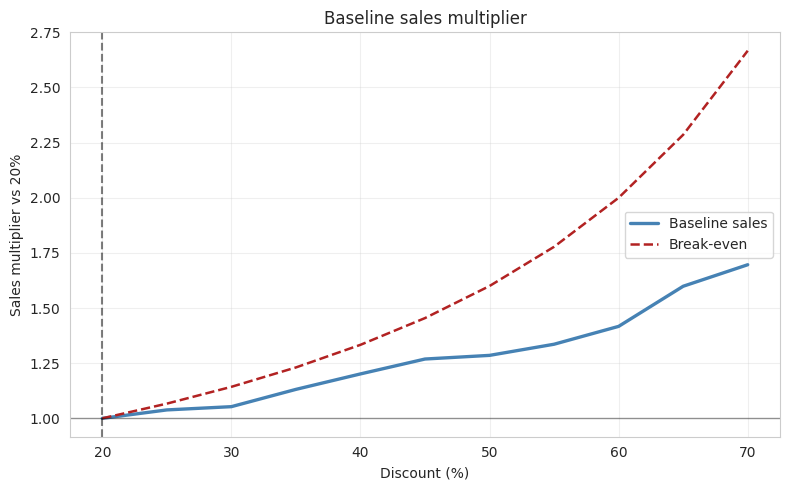

Baseline optimizer-behavior summary
{'low_rail': '75.78%', 'high_rail': '4.38%', 'interior': '19.84%', 'mean_opt_discount': 0.26675942115754886, 'median_opt_discount': 0.2, 'mean_rev_mult_opt': 2058302.6570657261, 'share_cross_break_even': '24.22%'}


In [0]:
def simulate_baseline_units(baseline, discount_grid):
    X_te_all = baseline["X_te_all"].copy()
    model = baseline["model"]
    treatment_col = baseline["baseline_treatment"]
    scale = outcome_scale_values(baseline["te_all"])

    yhat_units_matrix = []
    for d in discount_grid:
        X_te_all.loc[:, treatment_col] = float(d)
        yhat_model = model.predict(X_te_all)
        yhat_units = from_model_space(yhat_model, OUTCOME_SPACE) * scale
        yhat_units_matrix.append(yhat_units)

    yhat_units_matrix = np.column_stack(yhat_units_matrix)
    return yhat_units_matrix


def summarize_curve_from_matrix(yhat_units_matrix, discount_grid):
    rows = []
    for j, d in enumerate(discount_grid):
        rows.append({"discount": float(d), "yhat_mean": float(np.nanmean(yhat_units_matrix[:, j]))})
    curve = pd.DataFrame(rows).sort_values("discount").reset_index(drop=True)
    ref_idx = int(np.argmin(np.abs(curve["discount"].values - REF_DISCOUNT)))
    curve["sales_mult"] = curve["yhat_mean"] / max(curve["yhat_mean"].iloc[ref_idx], EPS)
    curve["revenue_mult"] = curve["sales_mult"] * (1 - curve["discount"]) / (1 - REF_DISCOUNT)
    return curve


baseline_units_matrix = simulate_baseline_units(baseline, DISCOUNT_GRID)
lgbm_curve = summarize_curve_from_matrix(baseline_units_matrix, DISCOUNT_GRID)
break_even = (1 - REF_DISCOUNT) / np.maximum(1 - DISCOUNT_GRID, EPS)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lgbm_curve["discount"] * 100, lgbm_curve["sales_mult"], lw=2.4, color="steelblue", label="Baseline sales")
ax.plot(DISCOUNT_GRID * 100, break_even, "--", color="firebrick", lw=1.8, label="Break-even")
ax.axvline(REF_DISCOUNT * 100, color="black", ls="--", alpha=0.5)
ax.axhline(1.0, color="black", lw=1, alpha=0.4)
ax.set_title("Baseline sales multiplier")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Sales multiplier vs 20%")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
savefig("baseline_curve")
plt.show()

baseline_revenue = baseline_units_matrix * (1.0 - DISCOUNT_GRID.reshape(1, -1))
baseline_opt_idx = np.nanargmax(baseline_revenue, axis=1)
baseline_opt_discount = DISCOUNT_GRID[baseline_opt_idx]

low_rail = float(np.mean(np.isclose(baseline_opt_discount, DISCOUNT_GRID.min())))
high_rail = float(np.mean(np.isclose(baseline_opt_discount, DISCOUNT_GRID.max())))
interior = float(1.0 - low_rail - high_rail)

baseline_curve_quality = {
    "low_rail": low_rail,
    "high_rail": high_rail,
    "interior": interior,
    "mean_opt_discount": float(np.nanmean(baseline_opt_discount)),
    "median_opt_discount": float(np.nanmedian(baseline_opt_discount)),
    "mean_rev_mult_opt": float(np.nanmean(np.nanmax(baseline_revenue, axis=1) / np.maximum(baseline_revenue[:, int(np.argmin(np.abs(DISCOUNT_GRID - REF_DISCOUNT)))], EPS))),
    "share_cross_break_even": float(np.mean(np.nanmax(baseline_revenue / np.maximum(baseline_revenue[:, int(np.argmin(np.abs(DISCOUNT_GRID - REF_DISCOUNT)))][:, None], EPS), axis=1) > 1.0)),
}

print("Baseline optimizer-behavior summary")
print({k: (f"{v:.2%}" if "discount" not in k and "mean_rev" not in k and "share" in k or "rail" in k or "interior" in k else v) for k, v in baseline_curve_quality.items()})


---
## 12) Choosing the specification

Before committing to a single causal model, I compare four candidate specifications: actual
price versus discount as the treatment, each in log-linear and log-log space. For every option I
residualise with DML and trace the implied sales-response curve, then judge which one behaves in
the most economically sensible and stable way. This diagnostic is what motivates the final
choice of specification.


Specification diagnostic | treatment=actual_price | space=log-linear
[train] scale filter removed 0 rows
✓ Treatment='actual_price' | No redundant confounders detected.
[train] rows=33,691 | confounders=17
[test] scale filter removed 0 rows
✓ Treatment='actual_price' | No redundant confounders detected.
[test] rows=146,983 | confounders=19
  Stage A folds: 3
  [tune] Fold 1/3 | ĝ iters=456 | l̂ iters=746
  [tune] Fold 2/3 | ĝ iters=368 | l̂ iters=482
  [tune] Fold 3/3 | ĝ iters=732 | l̂ iters=471
  Stage A summary: ĝ→519 | l̂→566
  [oof] Fold 1/3 | ĝ R²=0.9212 | l̂ R²=0.8856
  [oof] Fold 2/3 | ĝ R²=0.8930 | l̂ R²=0.9039
  [oof] Fold 3/3 | ĝ R²=0.8682 | l̂ R²=0.8993
  Final nuisance models trained on full train set.

Specification diagnostic | treatment=actual_price | space=log-log
[train] scale filter removed 0 rows
✓ Treatment='actual_price' | No redundant confounders detected.
[train] rows=33,691 | confounders=17
[test] scale filter removed 0 rows
✓ Treatment='actual_price' | No red

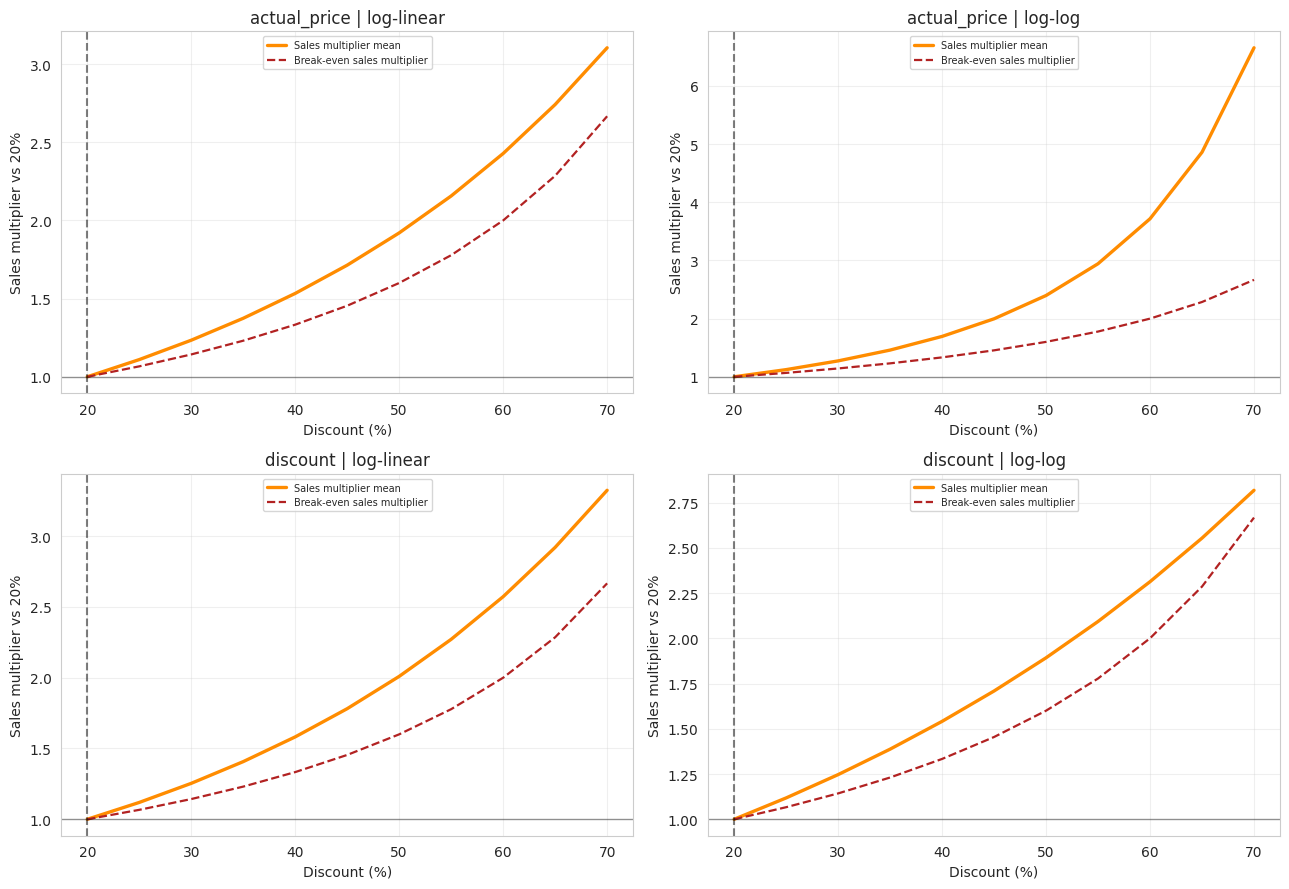

In [0]:
def _rebind_spec(treatment, modeling_space):
    global TREATMENT_RAW_COL, OUTCOME_RAW_COL, MODELING_SPACE
    global OUTCOME_SPACE, TREATMENT_SPACE, OUTCOME_COL, TREATMENT_COL
    TREATMENT_RAW_COL = treatment
    OUTCOME_RAW_COL = MODEL_CONFIG["outcome"]
    MODELING_SPACE = modeling_space
    OUTCOME_SPACE, TREATMENT_SPACE = modeling_space.split("-")
    OUTCOME_COL = f"log_{OUTCOME_RAW_COL}" if _is_log_space(OUTCOME_SPACE) else OUTCOME_RAW_COL
    TREATMENT_COL = f"log_{TREATMENT_RAW_COL}" if _is_log_space(TREATMENT_SPACE) else TREATMENT_RAW_COL


def fit_dml_residualization(train_weekly, test_weekly, treatment, modeling_space, conf_cols):
    _rebind_spec(treatment, modeling_space)

    tr_df, conf_u, season_col, _ = prepare_dataset(train_weekly, conf_cols, dataset_name="train")
    te_df, _, _, _ = prepare_dataset(test_weekly, conf_cols, dataset_name="test")

    n_iter_y, n_iter_t = tune_nuisance_hparams(tr_df, conf_u, season_col)
    tr_res, m_y, m_t = crossfit_oof_residuals(tr_df, conf_u, season_col, n_iter_y, n_iter_t)

    y_r2_oof = float(r2_score(tr_df["y_model"].values, tr_res["y_hat_oof"].values))
    t_r2_oof = float(r2_score(tr_df["t_model"].values, tr_res["t_hat_oof"].values))

    X_te = te_df[conf_u].copy()
    _, X_te_aligned, _ = encode_categoricals(tr_df[conf_u].copy(), X_te, conf_u)
    te_df["y_hat_test"] = m_y.predict(X_te_aligned)
    te_df["t_hat_test"] = m_t.predict(X_te_aligned)

    return {
        "tr_df": tr_df,
        "te_df": te_df,
        "tr_res": tr_res,
        "m_y": m_y,
        "m_t": m_t,
        "conf_used": conf_u,
        "treatment": treatment,
        "space": modeling_space,
        "outcome_space": OUTCOME_SPACE,
        "treatment_space": TREATMENT_SPACE,
        "n_iter_y": int(n_iter_y),
        "n_iter_t": int(n_iter_t),
        "n_folds": int(tr_df[season_col].nunique(dropna=True)),
        "y_r2_oof": y_r2_oof,
        "t_r2_oof": t_r2_oof,
        "y_res_std": float(np.nanstd(tr_res["y_res"])),
        "t_res_std": float(np.nanstd(tr_res["t_res"])),
    }


def per_row_discount_sweep_curve(
    fp_arr,
    y_hat_arr,
    t_hat_arr,
    effect_arr,
    scale_arr,
    treatment_raw_col,
    treatment_space,
    outcome_space,
    error_label,
):
    valid = (
        np.isfinite(fp_arr)
        & np.isfinite(y_hat_arr)
        & np.isfinite(t_hat_arr)
        & np.isfinite(effect_arr)
        & np.isfinite(scale_arr)
        & (fp_arr > 0)
    )
    if not valid.any():
        raise ValueError(error_label)

    rows = []
    for d in DISCOUNT_GRID:
        if treatment_raw_col == "actual_price":
            t_new_raw = fp_arr[valid] * (1.0 - float(d))
        elif treatment_raw_col == "discount":
            t_new_raw = np.full(valid.sum(), float(d), dtype=float)
        else:
            raise ValueError(f"Unsupported treatment in sweep: {treatment_raw_col}")

        t_new_model = to_model_space(t_new_raw, treatment_space)
        yhat_model = y_hat_arr[valid] + effect_arr[valid] * (t_new_model - t_hat_arr[valid])
        yhat_units = from_model_space(yhat_model, outcome_space) * scale_arr[valid]
        rows.append({
            "discount": float(d),
            "yhat_mean": float(np.nanmean(yhat_units)),
            "yhat_median": float(np.nanmedian(yhat_units)),
        })

    curve = pd.DataFrame(rows).sort_values("discount").reset_index(drop=True)
    ref_idx = int(np.argmin(np.abs(curve["discount"].values - REF_DISCOUNT)))
    curve["sales_mult"] = curve["yhat_mean"] / max(curve["yhat_mean"].iloc[ref_idx], EPS)
    curve["revenue_mult"] = curve["sales_mult"] * (1 - curve["discount"]) / (1 - REF_DISCOUNT)
    curve["sales_mult_median"] = curve["yhat_median"] / max(curve["yhat_median"].iloc[ref_idx], EPS)
    curve["revenue_mult_median"] = curve["sales_mult_median"] * (1 - curve["discount"]) / (1 - REF_DISCOUNT)
    return curve


SPEC_GRID = [
    ("actual_price", "log-linear"),
    ("actual_price", "log-log"),
    ("discount", "log-linear"),
    ("discount", "log-log"),
]

dml_results = {}
for treat, space in SPEC_GRID:
    print(f"\nSpecification diagnostic | treatment={treat} | space={space}")
    dml_results[(treat, space)] = fit_dml_residualization(train_weekly_model, test_weekly_model, treat, space, CONFOUNDER_COLS)

diag_rows = []
for (treat, space), r in dml_results.items():
    diag_rows.append(
        {
            "treatment": treat,
            "space": space,
            "y_r2_oof": r["y_r2_oof"],
            "t_r2_oof": r["t_r2_oof"],
            "std_y_res": r["y_res_std"],
            "std_t_res": r["t_res_std"],
            "folds": r["n_folds"],
        }
    )
diag_table = pd.DataFrame(diag_rows)
save_table(diag_table, "nuisance_diagnostics")

cate_results = {}
for treat, space in SPEC_GRID:
    print(f"\nCATE specification | treatment={treat} | space={space}")
    res = dml_results[(treat, space)]
    _rebind_spec(treat, space)

    tr_res = res["tr_res"].copy()
    te_df = res["te_df"].copy()
    tr_df = res["tr_df"].copy()
    conf_u = res["conf_used"]

    X_te = te_df[conf_u].copy()
    _, X_te_aligned, _ = encode_categoricals(tr_df[conf_u].copy(), X_te, conf_u)
    te_df["y_hat_test"] = res["m_y"].predict(X_te_aligned)
    te_df["t_hat_test"] = res["m_t"].predict(X_te_aligned)

    cf_model, _, Xh_columns, hetero_cols = fit_causal_forest(tr_res, conf_u)
    tr_res["tau_cf"] = predict_tau(cf_model, tr_res, hetero_cols, Xh_columns)
    te_df["tau_cf"] = predict_tau(cf_model, te_df, hetero_cols, Xh_columns)

    fp_arr = np.asarray(pd.to_numeric(te_df["full_price"], errors="coerce"), dtype=float)
    y_hat_arr = np.asarray(pd.to_numeric(te_df["y_hat_test"], errors="coerce"), dtype=float)
    t_hat_arr = np.asarray(pd.to_numeric(te_df["t_hat_test"], errors="coerce"), dtype=float)
    tau_arr = np.asarray(pd.to_numeric(te_df["tau_cf"], errors="coerce"), dtype=float)
    scale_arr = outcome_scale_values(te_df)

    curve = per_row_discount_sweep_curve(
        fp_arr=fp_arr,
        y_hat_arr=y_hat_arr,
        t_hat_arr=t_hat_arr,
        effect_arr=tau_arr,
        scale_arr=scale_arr,
        treatment_raw_col=treat,
        treatment_space=res["treatment_space"],
        outcome_space=res["outcome_space"],
        error_label=f"No valid rows for CATE diagnostic: {treat} | {space}",
    )

    cate_results[(treat, space)] = {
        "curve": curve,
        "tau_mean_test": float(np.nanmean(te_df["tau_cf"])),
    }

be = (1 - REF_DISCOUNT) / np.maximum(1 - DISCOUNT_GRID, EPS)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
for ax, (treat, space) in zip(axes.flat, SPEC_GRID):
    out = cate_results[(treat, space)]
    curve = out["curve"]
    ax.plot(DISCOUNT_GRID * 100, curve["sales_mult"], lw=2.4, color="darkorange", label="Sales multiplier mean")
    ax.plot(DISCOUNT_GRID * 100, be, "--", lw=1.6, color="firebrick", label="Break-even sales multiplier")
    ax.axhline(1.0, color="black", lw=1, alpha=0.4)
    ax.axvline(REF_DISCOUNT * 100, color="black", ls="--", alpha=0.5)
    ax.set_title(f"{treat} | {space}")
    ax.set_xlabel("Discount (%)")
    ax.set_ylabel("Sales multiplier vs 20%")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout()
savefig("cate_sales_spec_grid")
plt.show()



---
## 13) Final model and results

This section estimates the chosen specification from end to end: cross-fitted nuisance models, a
Causal Forest for the heterogeneous price effect, and the demand and revenue curves that follow
from it. I report the distribution of estimated effects across products, compare the causal
model against the predictive baseline, and export every figure and table used in the thesis,
including worked examples for individual products.

In [0]:
FINAL_SPEC = (MODEL_CONFIG["treatment"], MODEL_CONFIG["modeling_space"])
if FINAL_SPEC not in dml_results:
    dml_results[FINAL_SPEC] = fit_dml_residualization(train_weekly_model, test_weekly_model, FINAL_SPEC[0], FINAL_SPEC[1], CONFOUNDER_COLS)

final_dml = dml_results[FINAL_SPEC]
_rebind_spec(FINAL_SPEC[0], FINAL_SPEC[1])

final_tr = final_dml["tr_df"].copy()
final_te = final_dml["te_df"].copy()
final_res = final_dml["tr_res"].copy()
final_conf = final_dml["conf_used"]

X_te = final_te[final_conf].copy()
_, X_te_aligned, _ = encode_categoricals(final_tr[final_conf].copy(), X_te, final_conf)
final_te["y_hat_test"] = final_dml["m_y"].predict(X_te_aligned)
final_te["t_hat_test"] = final_dml["m_t"].predict(X_te_aligned)

cf_model, Xh_tr, Xh_columns, hetero_cols = fit_causal_forest(final_res, final_conf)
final_res["tau_cf"] = predict_tau(cf_model, final_res, hetero_cols, Xh_columns)
final_te["tau_cf"] = predict_tau(cf_model, final_te, hetero_cols, Xh_columns)

save_table(
    pd.DataFrame([{"parameter": k, "value": str(v)} for k, v in CF_PARAMS.items()]),
    "causal_forest_hyperparameters",
)

tau = pd.to_numeric(final_te["tau_cf"], errors="coerce").dropna()
cate_table = pd.DataFrame(
    [
        {"Statistic": "mean", "tau_hat": float(np.nanmean(tau))},
        {"Statistic": "median", "tau_hat": float(np.nanmedian(tau))},
        {"Statistic": "std", "tau_hat": float(np.nanstd(tau))},
        {"Statistic": "p5", "tau_hat": float(np.nanpercentile(tau, 5))},
        {"Statistic": "p25", "tau_hat": float(np.nanpercentile(tau, 25))},
        {"Statistic": "p75", "tau_hat": float(np.nanpercentile(tau, 75))},
        {"Statistic": "p95", "tau_hat": float(np.nanpercentile(tau, 95))},
        {"Statistic": "share negative", "tau_hat": float(np.mean(tau < 0))},
        {"Statistic": "share positive", "tau_hat": float(np.mean(tau > 0))},
    ]
)
save_table(cate_table, "cate_distribution")



  CausalForest fitted | hetero=17 → one-hot=52
Saved table: thesis_outputs/tables/causal_forest_hyperparameters.csv
Saved table: thesis_outputs/tables/cate_distribution.csv


In [0]:
def simulate_causal_units_matrix(te_df, treatment_raw_col, treatment_space, outcome_space):
    fp_arr = np.asarray(pd.to_numeric(te_df["full_price"], errors="coerce"), dtype=float)
    y_hat_arr = np.asarray(pd.to_numeric(te_df["y_hat_test"], errors="coerce"), dtype=float)
    t_hat_arr = np.asarray(pd.to_numeric(te_df["t_hat_test"], errors="coerce"), dtype=float)
    tau_arr = np.asarray(pd.to_numeric(te_df["tau_cf"], errors="coerce"), dtype=float)
    scale_arr = outcome_scale_values(te_df)

    valid = (
        np.isfinite(fp_arr)
        & np.isfinite(y_hat_arr)
        & np.isfinite(t_hat_arr)
        & np.isfinite(tau_arr)
        & np.isfinite(scale_arr)
        & (fp_arr > 0)
    )

    units_matrix = np.full((len(te_df), len(DISCOUNT_GRID)), np.nan)
    for j, d in enumerate(DISCOUNT_GRID):
        if treatment_raw_col == "actual_price":
            t_new_raw = fp_arr[valid] * (1.0 - float(d))
        else:
            t_new_raw = np.full(valid.sum(), float(d), dtype=float)
        t_new_model = to_model_space(t_new_raw, treatment_space)
        yhat_model = y_hat_arr[valid] + tau_arr[valid] * (t_new_model - t_hat_arr[valid])
        units_matrix[valid, j] = from_model_space(yhat_model, outcome_space) * scale_arr[valid]

    return units_matrix, valid


causal_units_matrix, causal_valid = simulate_causal_units_matrix(
    final_te,
    treatment_raw_col=FINAL_SPEC[0],
    treatment_space=final_dml["treatment_space"],
    outcome_space=final_dml["outcome_space"],
)
causal_curve = summarize_curve_from_matrix(causal_units_matrix[causal_valid], DISCOUNT_GRID)

causal_revenue = causal_units_matrix * (1.0 - DISCOUNT_GRID.reshape(1, -1))
causal_opt_idx = np.nanargmax(causal_revenue, axis=1)
causal_opt_discount = DISCOUNT_GRID[causal_opt_idx]

low_rail_c = float(np.mean(np.isclose(causal_opt_discount[causal_valid], DISCOUNT_GRID.min())))
high_rail_c = float(np.mean(np.isclose(causal_opt_discount[causal_valid], DISCOUNT_GRID.max())))
interior_c = float(1.0 - low_rail_c - high_rail_c)

ref_idx = int(np.argmin(np.abs(DISCOUNT_GRID - REF_DISCOUNT)))
causal_curve_quality = {
    "low_rail": low_rail_c,
    "high_rail": high_rail_c,
    "interior": interior_c,
    "mean_opt_discount": float(np.nanmean(causal_opt_discount[causal_valid])),
    "median_opt_discount": float(np.nanmedian(causal_opt_discount[causal_valid])),
    "mean_rev_mult_opt": float(np.nanmean(np.nanmax(causal_revenue[causal_valid], axis=1) / np.maximum(causal_revenue[causal_valid, ref_idx], EPS))),
    "share_cross_break_even": float(np.mean((np.nanmax(causal_revenue[causal_valid], axis=1) / np.maximum(causal_revenue[causal_valid, ref_idx], EPS)) > 1.0)),
}

curve_quality_table = pd.DataFrame(
    [
        {
            "Model": "LightGBM baseline",
            "Low rail optimum %": baseline_curve_quality["low_rail"],
            "High rail optimum %": baseline_curve_quality["high_rail"],
            "Interior optimum %": baseline_curve_quality["interior"],
            "Mean optimal discount": baseline_curve_quality["mean_opt_discount"],
            "Median optimal discount": baseline_curve_quality["median_opt_discount"],
            "Mean revenue multiplier at optimum": baseline_curve_quality["mean_rev_mult_opt"],
            "Share crossing break-even": baseline_curve_quality["share_cross_break_even"],
        },
        {
            "Model": "Causal Forest",
            "Low rail optimum %": causal_curve_quality["low_rail"],
            "High rail optimum %": causal_curve_quality["high_rail"],
            "Interior optimum %": causal_curve_quality["interior"],
            "Mean optimal discount": causal_curve_quality["mean_opt_discount"],
            "Median optimal discount": causal_curve_quality["median_opt_discount"],
            "Mean revenue multiplier at optimum": causal_curve_quality["mean_rev_mult_opt"],
            "Share crossing break-even": causal_curve_quality["share_cross_break_even"],
        },
    ]
)
save_table(curve_quality_table, "curve_quality")


Saved table: thesis_outputs/tables/curve_quality.csv


Saved table: thesis_outputs/tables/optimizer_interface.csv
Saved figure: thesis_outputs/figures/elasticity_examples_baseline_vs_causal.png


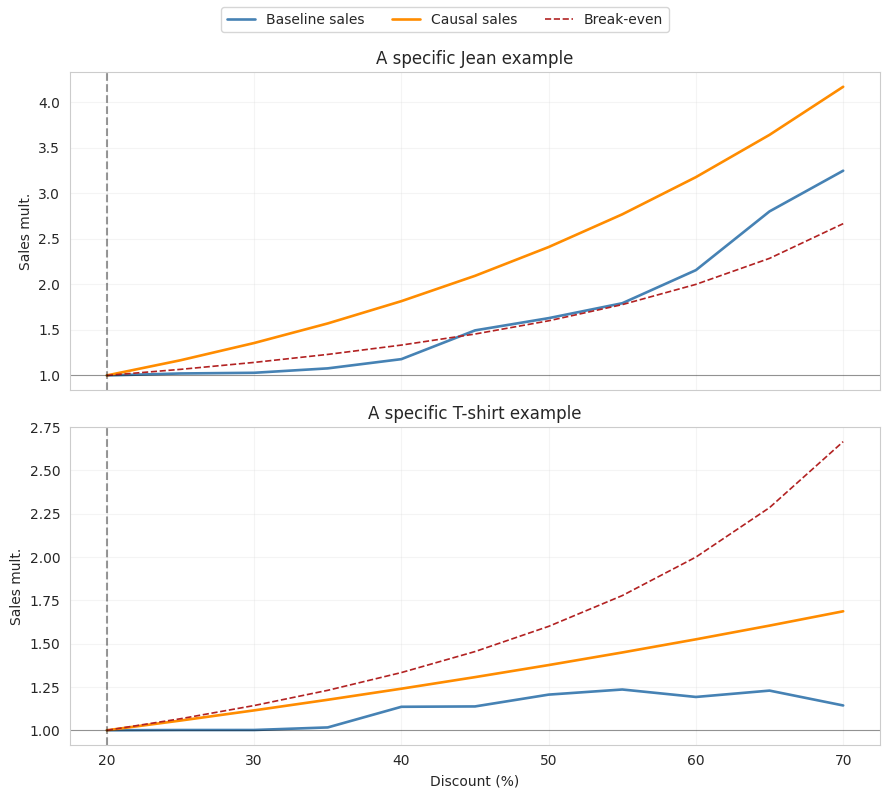

In [0]:
# Reference-level example selection (for optimizer interface and profile examples)
n_common = min(causal_units_matrix.shape[0], baseline_units_matrix.shape[0], len(final_te))
valid_rows = np.where(causal_valid[:n_common])[0]
if len(valid_rows) == 0:
    raise ValueError("No valid rows for final CATE reference example.")

curve_rows = []
for i in valid_rows:
    units_c = causal_units_matrix[i, :]
    units_b = baseline_units_matrix[i, :]
    if (not np.all(np.isfinite(units_c))) or (not np.all(np.isfinite(units_b))):
        continue
    if units_c[ref_idx] <= 0 or units_b[ref_idx] <= 0:
        continue

    sales_mult_c = units_c / max(units_c[ref_idx], EPS)
    revenue_mult_c = sales_mult_c * (1.0 - DISCOUNT_GRID) / (1.0 - REF_DISCOUNT)
    if not np.all(np.isfinite(sales_mult_c)) or not np.all(np.isfinite(revenue_mult_c)):
        continue

    tau = pd.to_numeric(pd.Series([final_te["tau_cf"].iloc[i]]), errors="coerce").iloc[0]
    full_price = pd.to_numeric(pd.Series([final_te["full_price"].iloc[i]]), errors="coerce").iloc[0]
    if not np.isfinite(tau) or not np.isfinite(full_price):
        continue

    opt_idx_c = int(np.nanargmax(revenue_mult_c))
    curve_rows.append({
        "row_pos": int(i),
        "tau": float(tau),
        "full_price": float(full_price),
        "implied_elasticity_ref": float(tau * full_price * (1.0 - REF_DISCOUNT)),
        "opt_discount": float(DISCOUNT_GRID[opt_idx_c]),
        "max_sales_mult": float(np.nanmax(sales_mult_c)),
        "max_revenue_mult": float(np.nanmax(revenue_mult_c)),
        "interior_opt": bool((opt_idx_c > 0) and (opt_idx_c < len(DISCOUNT_GRID) - 1)),
    })

curve_candidates = pd.DataFrame(curve_rows)
if len(curve_candidates) == 0:
    raise ValueError("No finite candidates for final CATE reference example.")

reasonable = curve_candidates[
    (curve_candidates["tau"] < 0)
    & (curve_candidates["interior_opt"])
    & (curve_candidates["max_sales_mult"] <= 3.0)
    & (curve_candidates["max_revenue_mult"] <= 1.8)
].copy()

if len(reasonable) == 0:
    print("No moderate interior candidate found. Relaxing filters.")
    reasonable = curve_candidates[
        (curve_candidates["tau"] < 0)
        & (curve_candidates["max_sales_mult"] <= 5.0)
    ].copy()

if len(reasonable) == 0:
    print("No filtered candidate found. Falling back to median tau.")
    tau_valid = np.asarray(pd.to_numeric(final_te["tau_cf"].iloc[valid_rows], errors="coerce"), dtype=float)
    target_tau = np.nanmedian(tau_valid)
    row_choice = int(valid_rows[int(np.nanargmin(np.abs(tau_valid - target_tau)))])
else:
    target_elasticity = float(np.nanmedian(reasonable["implied_elasticity_ref"]))
    reasonable["score"] = np.abs(reasonable["implied_elasticity_ref"] - target_elasticity)
    row_choice = int(reasonable.sort_values("score").iloc[0]["row_pos"])

row_units_c = causal_units_matrix[row_choice, :]
row_units_b = baseline_units_matrix[row_choice, :]
row_sales_mult_c = row_units_c / max(row_units_c[ref_idx], EPS)
row_revenue_mult_c = row_sales_mult_c * (1.0 - DISCOUNT_GRID) / (1.0 - REF_DISCOUNT)
row_sales_mult_b = row_units_b / max(row_units_b[ref_idx], EPS)
row_revenue_mult_b = row_sales_mult_b * (1.0 - DISCOUNT_GRID) / (1.0 - REF_DISCOUNT)
row_opt_idx_c = int(np.nanargmax(row_revenue_mult_c))
row_opt_idx_b = int(np.nanargmax(row_revenue_mult_b))

optimizer_interface_table = pd.DataFrame({
    "discount": [f"{d:.0%}" for d in DISCOUNT_GRID],
    "baseline_sales_multiplier": row_sales_mult_b,
    "causal_sales_multiplier": row_sales_mult_c,
    "baseline_revenue_multiplier": row_revenue_mult_b,
    "causal_revenue_multiplier": row_revenue_mult_c,
})
save_table(optimizer_interface_table, "optimizer_interface")

# Two row-level examples by category at median elasticity (P50)
example_pool = []
for i in valid_rows:
    units_c = causal_units_matrix[i, :]
    units_b = baseline_units_matrix[i, :]
    if (not np.all(np.isfinite(units_c))) or (not np.all(np.isfinite(units_b))):
        continue
    if units_c[ref_idx] <= 0 or units_b[ref_idx] <= 0:
        continue
    example_pool.append(int(i))

if len(example_pool) == 0:
    raise ValueError("No rows available for elasticity-profile example grid.")

eligible = curve_candidates[curve_candidates["row_pos"].isin(example_pool)].copy()
if len(eligible) == 0:
    raise ValueError("No eligible rows with elasticity diagnostics for category examples.")

family_col = "product_aggregated_family_id_given_cod_mc_base_relabelled"
if family_col not in final_te.columns:
    raise ValueError(f"Required category column missing in final_te: {family_col}")

eligible["family_category"] = np.asarray(
    pd.to_numeric(final_te.iloc[eligible["row_pos"].astype(int)][family_col], errors="coerce"),
    dtype=float,
)
eligible = eligible[np.isfinite(eligible["family_category"])].copy()
if len(eligible) == 0:
    raise ValueError("No eligible rows with valid family categories for category examples.")

category_specs = [
    (16, "A specific Jean example"),
    (14, "A specific T-shirt example"),
]

selected_examples = []
for category_id, display_title in category_specs:
    subset = eligible[np.isclose(eligible["family_category"], float(category_id))].copy()
    if len(subset) == 0:
        raise ValueError(f"No eligible rows for category {category_id} in category examples.")

    subset_vals = np.asarray(pd.to_numeric(subset["implied_elasticity_ref"], errors="coerce"), dtype=float)
    if not np.isfinite(subset_vals).any():
        raise ValueError(f"No finite elasticity values for category {category_id}.")

    target_el = float(np.nanpercentile(subset_vals, 50))
    subset["dist"] = np.abs(subset["implied_elasticity_ref"] - target_el)
    chosen = subset.sort_values("dist").iloc[0]

    ridx = int(chosen["row_pos"])
    selected_examples.append({
        "title": display_title,
        "family_category": int(category_id),
        "row_pos": ridx,
        "elasticity_ref": float(chosen["implied_elasticity_ref"]),
    })

examples_df = pd.DataFrame(selected_examples)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
for r, ex in enumerate(selected_examples):
    ridx = int(ex["row_pos"])
    units_b = baseline_units_matrix[ridx, :]
    units_c = causal_units_matrix[ridx, :]

    b_sales = units_b / max(units_b[ref_idx], EPS)
    c_sales = units_c / max(units_c[ref_idx], EPS)
    ax_s = axes[r]
    ax_s.plot(DISCOUNT_GRID * 100, b_sales, lw=1.9, color="steelblue", label="Baseline sales")
    ax_s.plot(DISCOUNT_GRID * 100, c_sales, lw=1.9, color="darkorange", label="Causal sales")
    ax_s.plot(DISCOUNT_GRID * 100, break_even, "--", lw=1.2, color="firebrick", label="Break-even")
    ax_s.axhline(1.0, color="black", lw=0.8, alpha=0.4)
    ax_s.axvline(REF_DISCOUNT * 100, color="black", ls="--", alpha=0.4)
    ax_s.set_ylabel("Sales mult.")
    ax_s.set_title(ex["title"])
    ax_s.grid(alpha=0.2)

axes[-1].set_xlabel("Discount (%)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.96])
savefig("elasticity_examples_baseline_vs_causal")
plt.show()


Saved figure: thesis_outputs/figures/global_comparison.png


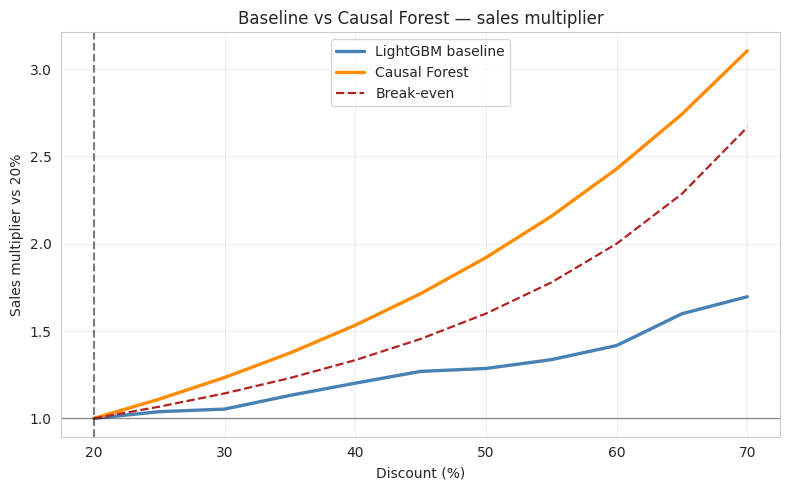

Causal Forest holdout metrics computed on observed y only: N=12,136
Saved table: thesis_outputs/tables/model_metrics.csv
Saved figure: thesis_outputs/figures/dml_residualized_treatment_outcome_linear.png


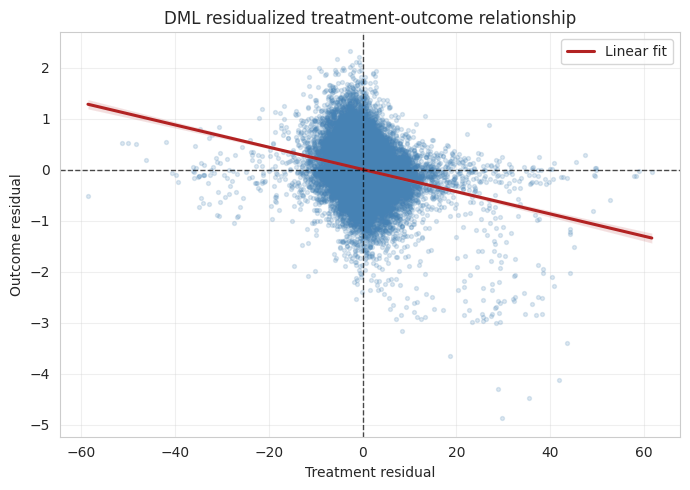

In [0]:
# Global comparison baseline vs causal forest
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lgbm_curve["discount"] * 100, lgbm_curve["sales_mult"], lw=2.4, color="steelblue", label="LightGBM baseline")
ax.plot(causal_curve["discount"] * 100, causal_curve["sales_mult"], lw=2.4, color="darkorange", label="Causal Forest")
ax.plot(DISCOUNT_GRID * 100, break_even, "--", lw=1.6, color="firebrick", label="Break-even")
ax.axhline(1.0, color="black", lw=1, alpha=0.4)
ax.axvline(REF_DISCOUNT * 100, color="black", ls="--", alpha=0.5)
ax.set_title("Baseline vs Causal Forest — sales multiplier")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Sales multiplier vs 20%")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
savefig("global_comparison")
plt.show()

# Metrics table for thesis main comparison
def safe_regression_metrics(y_true, y_pred):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    n = int(mask.sum())
    if n == 0:
        return {"wmape": np.nan, "r2": np.nan, "n": 0}
    wm = float(wmape(y_true[mask], y_pred[mask]))
    if n < 2:
        return {"wmape": wm, "r2": np.nan, "n": n}
    return {"wmape": wm, "r2": float(r2_score(y_true[mask], y_pred[mask])), "n": n}


final_tr = final_res.copy()
final_tr["pred_model"] = final_tr["y_hat_oof"] + final_tr["tau_cf"] * (final_tr["t_model"] - final_tr["t_hat_oof"])
final_tr["pred_raw"] = from_model_space(final_tr["pred_model"].values, final_dml["outcome_space"])
final_tr["y_raw"] = from_model_space(final_tr["y_model"].values, final_dml["outcome_space"])
tr_true_units = to_weekly_units(final_tr["y_raw"].values, final_tr)
tr_pred_units = to_weekly_units(final_tr["pred_raw"].values, final_tr)
cf_train_metrics = safe_regression_metrics(tr_true_units, tr_pred_units)

t_obs_model = to_model_space(final_te[FINAL_SPEC[0]], final_dml["treatment_space"])
final_te["pred_model"] = final_te["y_hat_test"] + final_te["tau_cf"] * (t_obs_model - final_te["t_hat_test"])
final_te["pred_raw"] = from_model_space(final_te["pred_model"].values, final_dml["outcome_space"])
te_true_units = to_weekly_units(final_te[OUTCOME_RAW_COL].values, final_te)
te_pred_units = to_weekly_units(final_te["pred_raw"].values, final_te)
cf_test_metrics = safe_regression_metrics(te_true_units, te_pred_units)

if cf_test_metrics["n"] == 0:
    print("WARNING: No observed holdout y_week rows for Causal Forest test metrics.")
else:
    print(f"Causal Forest holdout metrics computed on observed y only: N={cf_test_metrics['n']:,}")

metrics_table = pd.DataFrame([
    {
        "Model": "LightGBM baseline",
        "Split": "Train OOF",
        "WMAPE": baseline["metrics"]["train_oof_wmape"],
        "R2": baseline["metrics"]["train_oof_r2"],
        "N": baseline["metrics"]["train_n"],
    },
    {
        "Model": "LightGBM baseline",
        "Split": "Test",
        "WMAPE": baseline["metrics"]["test_wmape"],
        "R2": baseline["metrics"]["test_r2"],
        "N": baseline["metrics"]["test_n"],
    },
    {
        "Model": "Causal Forest",
        "Split": "Train OOF",
        "WMAPE": cf_train_metrics["wmape"],
        "R2": cf_train_metrics["r2"],
        "N": cf_train_metrics["n"],
    },
    {
        "Model": "Causal Forest",
        "Split": "Test (observed y)",
        "WMAPE": cf_test_metrics["wmape"],
        "R2": cf_test_metrics["r2"],
        "N": cf_test_metrics["n"],
    },
])
save_table(metrics_table, "model_metrics")

# DML residualized treatment-outcome diagnostic with linear fit
plot_df = final_res[["t_res", "y_res"]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(7, 5))
sns.regplot(
    data=plot_df,
    x="t_res",
    y="y_res",
    scatter_kws={"alpha": 0.18, "s": 8, "color": "steelblue"},
    line_kws={"color": "firebrick", "linewidth": 2.2, "label": "Linear fit"},
    ci=95,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
plt.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
plt.xlabel("Treatment residual")
plt.ylabel("Outcome residual")
plt.title("DML residualized treatment-outcome relationship")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
savefig("dml_residualized_treatment_outcome_linear")
plt.show()


In [0]:
# Final thesis outputs checklist
save_all_tables_txt(THESIS_TABLES)

all_outputs = []
for fig_name in THESIS_FIGURES:
    all_outputs.append((f"{FIG_DIR}/{fig_name}.png", os.path.exists(f"{FIG_DIR}/{fig_name}.png")))
for tab_name in THESIS_TABLES:
    all_outputs.append((f"{TAB_DIR}/{tab_name}.csv", os.path.exists(f"{TAB_DIR}/{tab_name}.csv")))
all_outputs.append((ALL_TABLES_TXT, os.path.exists(ALL_TABLES_TXT)))

checklist_df = pd.DataFrame(all_outputs, columns=["artifact", "exists"])
print("\nThesis outputs checklist")
for _, row in checklist_df.iterrows():
    status = "OK" if row["exists"] else "MISSING"
    print(f"{status:8s} {row['artifact']}")

missing = checklist_df.loc[~checklist_df["exists"], "artifact"].tolist()
if missing:
    raise RuntimeError(f"Missing thesis outputs: {missing}")


Saved combined tables TXT: thesis_outputs/tables/all_tables_compendium.txt

Thesis outputs checklist
OK       thesis_outputs/figures/baseline_curve.png
OK       thesis_outputs/figures/cate_sales_spec_grid.png
OK       thesis_outputs/figures/global_comparison.png
OK       thesis_outputs/figures/elasticity_examples_baseline_vs_causal.png
OK       thesis_outputs/figures/dml_residualized_treatment_outcome_linear.png
OK       thesis_outputs/tables/dataset_summary.csv
OK       thesis_outputs/tables/treatment_support.csv
OK       thesis_outputs/tables/model_config.csv
OK       thesis_outputs/tables/nuisance_diagnostics.csv
OK       thesis_outputs/tables/model_metrics.csv
OK       thesis_outputs/tables/cate_distribution.csv
OK       thesis_outputs/tables/curve_quality.csv
OK       thesis_outputs/tables/optimizer_interface.csv
OK       thesis_outputs/tables/lgbm_hyperparameters.csv
OK       thesis_outputs/tables/causal_forest_hyperparameters.csv
OK       thesis_outputs/tables/all_tables_compend